In [1]:
try:
    import xgboost as xgb
    import lightgbm as lgb
    import catboost as cgb
except:
    %pip install -q -U xgboost lightgbm catboost
    import xgboost as xgb
    import lightgbm as lgb
    import catboost as cgb

In [2]:
!pip show xgboost catboost lightgbm

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: TPOT
---
Name: catboost
Version: 1.2.10
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 
---
Name: lightgbm
Version: 4.6.0
Summary: LightGBM Python-package
Home-page: https://github.com/microsoft/LightGBM
Author: 
Author-email: 
License: The MIT License (MIT)

Copyright (c) Microsoft Corporation

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without re

In [3]:
# !pip install -qq -U hvplot
# import hvplot.pandas
# hvplot.extension('matplotlib')

## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    get_ipython().run_line_magic('load_ext', 'cuml.accel')
    from cuml.preprocessing import TargetEncoder as cuTE

ℹ️ Running on Cuda: False


In [4]:
## -- System dependencies --
import sys, os, gc

## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

## -- Functional Tools --
from time import time, sleep
from tqdm.auto import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegressionCV, RidgeCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.calibration import CalibrationDisplay
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, train_test_split

import warnings

2026-05-03 10:44:47.192552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777805087.468619      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777805087.552155      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777805088.243315      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777805088.243367      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777805088.243369      16 computation_placer.cc:177] computation placer alr

In [5]:
print(f"xgboost  version: {xgb.__version__}")
print(f"lightgbm version: {lgb.__version__}")
print(f"catboost version: {cgb.__version__}")

xgboost  version: 3.2.0
lightgbm version: 4.6.0
catboost version: 1.2.10


In [6]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
class CFG():
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

tf.keras.utils.set_random_seed(CFG.SEED)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

CLASSIC  GREEN   YELLOW 


In [7]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [8]:
## -- Check if id is unique --
# print(f"Train ID column is unique: {train.id.is_unique}")
# print(f"Test  ID column is unique: {test.id.is_unique}")

In [9]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [10]:
train.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026
RaceProgress,439140.0,0.337661,0.253277,0.012821,0.12987,0.269231,0.513158,1.000


In [11]:
train.describe(exclude=np.number)

,Driver,Compound,Race
count,439140,439140,439140
unique,887,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,1682,211141,24462


In [12]:
display(test.head())
test.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188165 entries, 0 to 188164
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  188165 non-null  object 
 1   Compound                188165 non-null  object 
 2   Race                    188165 non-null  object 
 3   Year                    188165 non-null  int64  
 4   PitStop                 188165 non-null  int64  
 5   LapNumber               188165 non-null  int64  
 6   Stint                   188165 non-null  int64  
 7   TyreLife                188165 non-null  float64
 8   Position                188165 non-null  int64  
 9   LapTime (s)             188165 non-null  float64
 10  LapTime_Delta           188165 non-null  float64
 11  Cumulative_Degradation  188165 non-null  float64
 12  RaceProgress            188165 non-null  float64
 13  Position_Change         188165 non-null  float64
dtypes: float64(6), int64

In [13]:
display(orig.head())
orig.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,ALB,MEDIUM,Abu Dhabi Grand Prix,2023,0,1,1,2.0,17,100.625,0.000,0.000,0.017241,0.0,0
1,ALB,MEDIUM,Abu Dhabi Grand Prix,2023,0,2,1,3.0,18,93.560,-7.065,-7.065,0.034483,-1.0,0
2,ALB,MEDIUM,Abu Dhabi Grand Prix,2023,0,3,1,4.0,18,91.768,-1.792,-8.857,0.051724,0.0,0
3,ALB,MEDIUM,Abu Dhabi Grand Prix,2023,0,4,1,5.0,18,91.591,-0.177,-9.034,0.068966,0.0,0
4,ALB,MEDIUM,Abu Dhabi Grand Prix,2023,0,5,1,6.0,18,91.422,-0.169,-9.203,0.086207,0.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   Compound                101305 non-null  object 
 2   Race                    101371 non-null  object 
 3   Year                    101371 non-null  int64  
 4   PitStop                 101371 non-null  int64  
 5   LapNumber               101371 non-null  int64  
 6   Stint                   101371 non-null  int64  
 7   TyreLife                101371 non-null  float64
 8   Position                101371 non-null  int64  
 9   LapTime (s)             101371 non-null  float64
 10  LapTime_Delta           101371 non-null  float64
 11  Cumulative_Degradation  101371 non-null  float64
 12  RaceProgress            101371 non-null  float64
 13  Position_Change         101371 non-null  float64
 14  PitNextLap          

In [14]:
# Check if column names are the same regardless of order
are_same_set = set(train.columns) == set(orig.columns)
print(f"Are column names the same regardless of order (train vs orig)? {are_same_set}")

# Check if column names are the same and in the same order
are_same_exact = train.columns.equals(orig.columns)
print(f"Are column names exactly the same and in the same order (train vs orig)? {are_same_exact}")

Are column names the same regardless of order (train vs orig)? True
Are column names exactly the same and in the same order (train vs orig)? True


In [15]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


### YDATA-PROFILE REPORT

In [16]:
# # %%capture
# ## -- Comprehensive EDA --
# !{sys.executable} -m pip install -qq -U ydata-profiling[notebook]
# !pip install -qq jupyter-contrib-nbextensions
# !jupyter nbextension enable --py widgetsnbextension

In [17]:
# from ydata_profiling import ProfileReport, compare

# ## -- Single EDA --
# # profile_df = ProfileReport(train, title="Insights into TARGET Types", explorative=True)
# # profile_df.to_notebook_iframe()

# # profile_df.to_file("Loan_EDA_Report.html")

# ## -- Create Profiles for Datasets --
# train_report = ProfileReport(train, title="Train", explorative=True)
# # test_report = ProfileReport(test, title="Test", explorative=True)
# orig_report = ProfileReport(orig, title="Original", explorative=True)

# ## -- Compare 2++ Datasets --
# comparison_report = compare([train_report, test_report])

# # ## -- Obtain merged statistics (Don't know its purpose yet)
# # statistics = comparison_report.get_description()
# ## -- Save report to file
# comparison_report.to_file("Student Test Scores | Train-Orig_Stats.html")
# comparison_report.to_notebook_iframe()

# EDA

## ~ NUMERIC

In [18]:
# ## -- PLOT TARGET DISTRIBUTION --
# # plt.figure(figsize=(16, 6))
# _, axs = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios':[0.7, 0.3], 'wspace':0.1})

# ## -- KDEs --
# sns.kdeplot(data=train, x=TARGET, color=PALETTE[0], linewidth=2, ax=axs[0], label='Train')
# sns.kdeplot(data=orig, x=TARGET, color=PALETTE[1], linewidth=2, ax=axs[0], label='Original')
# axs[0].legend()
# axs[0].set_xlabel('')

# # Boxplots
# # pd.concat([train[[TARGET]], orig[[TARGET]]], axis=1).boxplot(
# #     widths=0.6,
# #     showmeans=True,
# #     # meanline=True,
# #     # patch_artist=True,
# #     # notch=True,
# #     # labels=['Train', 'Original'],
# #     ax=axs[1])

# sns.violinplot(
#     data=[train[TARGET].values, orig[TARGET].values],
#     inner='quart',
#     width=0.6,
#     # size=1,
#     # width=0.6,
#     # linewidth=2,
#     # fliersize=.1,
#     ax=axs[1],
#     palette=PALETTE)

# axs[1].set_xticklabels(['Train', 'Original'], fontdict={'weight': 'bold'})

# plt.suptitle(f"- Target '{TARGET}' distribution -", fontsize=15, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [19]:
def distplots_data(train: pd.DataFrame, test: pd.DataFrame, orig: pd.DataFrame, features: list[str]):
    # 1) Concatenate data
    df = pd.concat([
            train[features].assign(Source='Train'),
            test[features].assign(Source='Test'),
            orig[features].assign(Source='Original')
    ], ignore_index=True)

    for i, col in enumerate(features):
        _, axs = plt.subplots(
            1, 2,
            figsize=(18, 5),
            gridspec_kw={'hspace': 0.3, 'wspace': 0.15, 'width_ratios': [0.7, 0.3]}
        )
        ## -- KDE plots --
        sns.kdeplot(data=train, x=col, linewidth=2, ax=axs[0], label='Train')
        sns.kdeplot(data=test, x=col, linewidth=2, ax=axs[0], label='Test')
        sns.kdeplot(data=orig, x=col, linewidth=2, ax=axs[0], label='Orig')
        axs[0].set_title(f'\n{col}', fontdict={'size': 15, 'weight': 'bold'})
        axs[0].set(xlabel='')
        axs[0].legend()

        ## -- BOX plots --
        sns.boxplot(
            data=df,
            y=col,
            x='Source',
            width=0.5,
            linewidth=2,
            ax=axs[1],
            palette=PALETTE
        )
        axs[1].set(xlabel='')
        axs[1].tick_params(axis='both', which='major')
        axs[1].set_xticklabels(['Train', 'Test', 'Original'], fontweight='semibold')

    plt.tight_layout()
    plt.show()

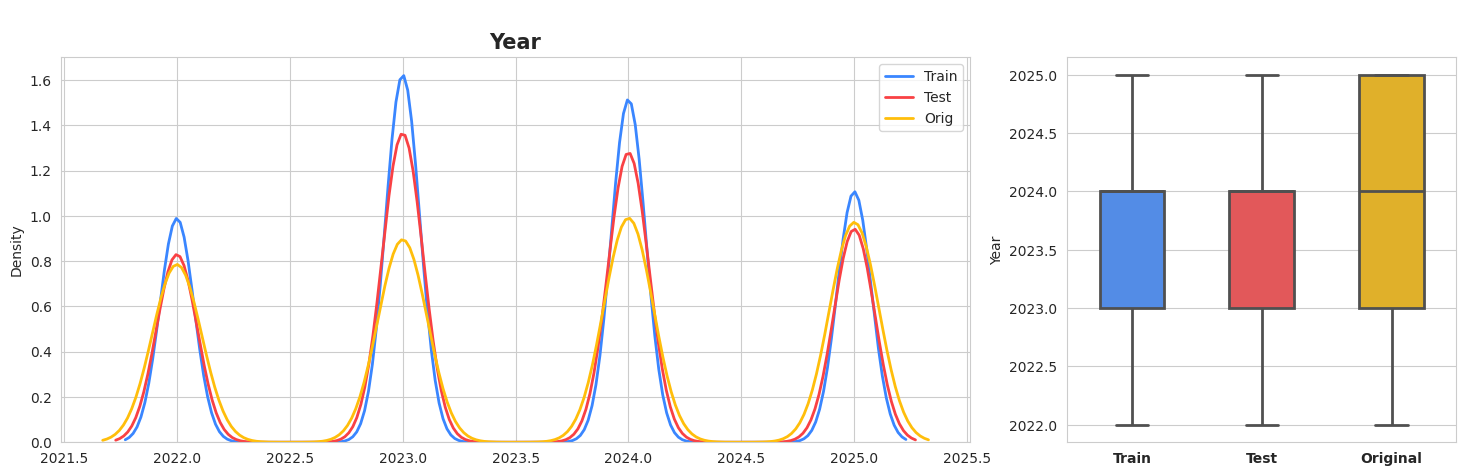

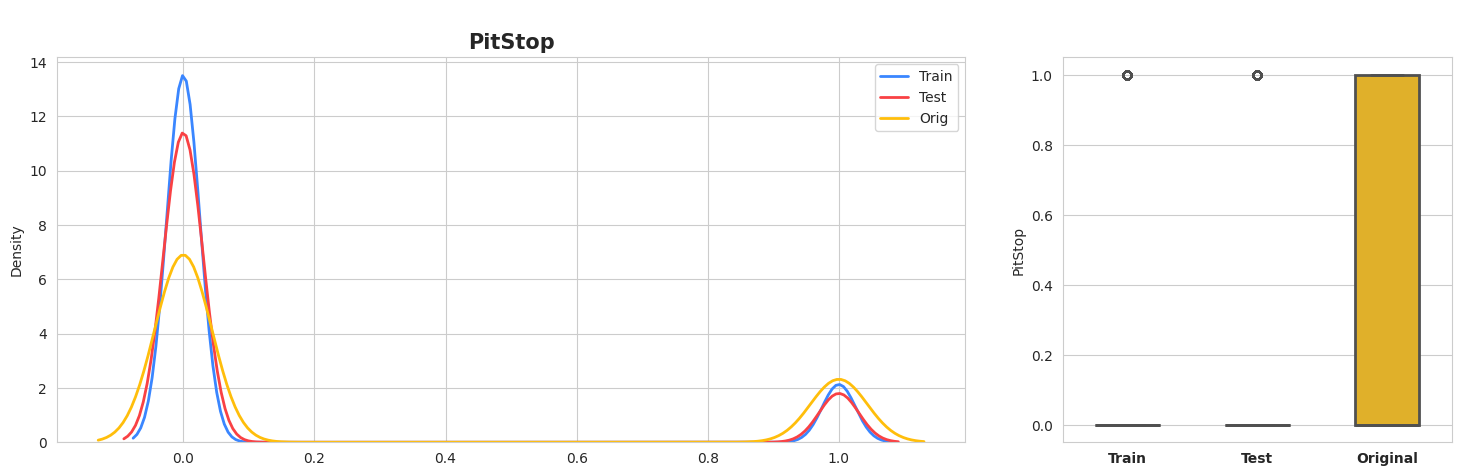

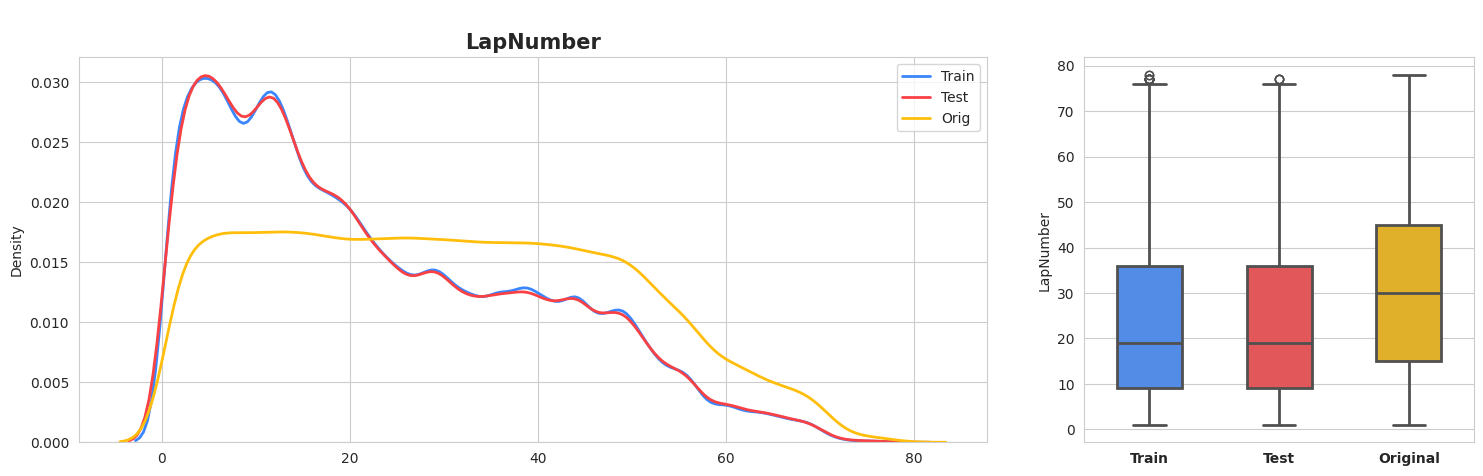

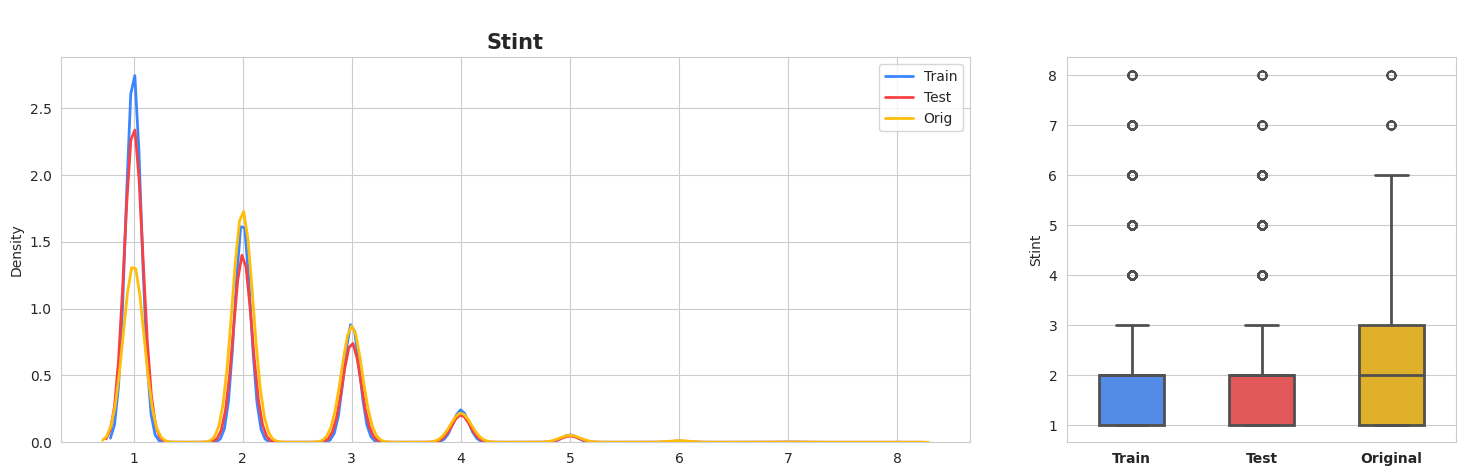

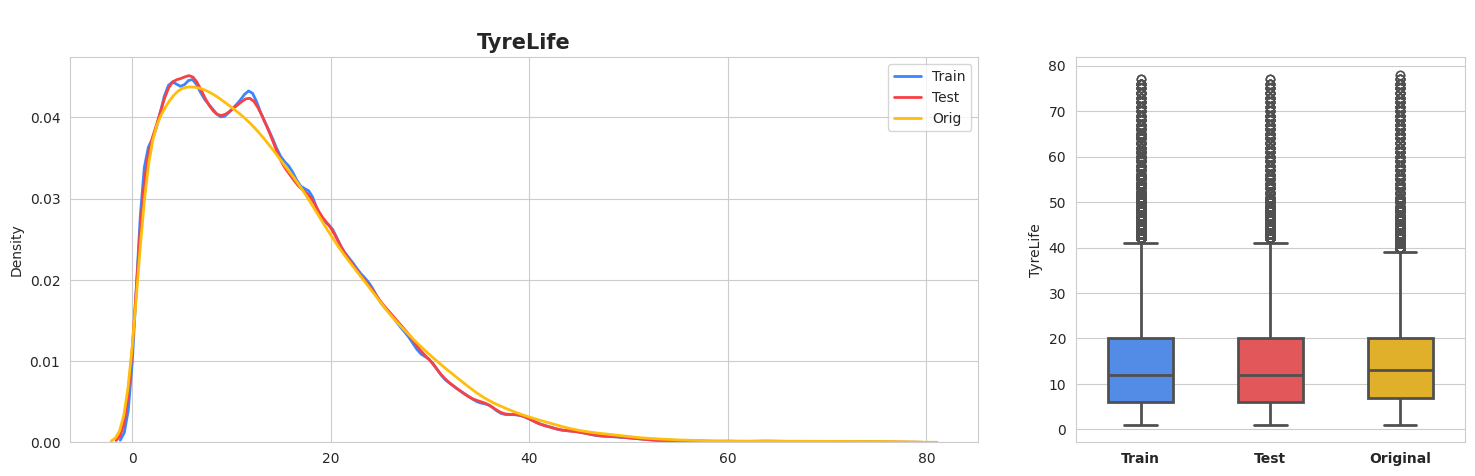

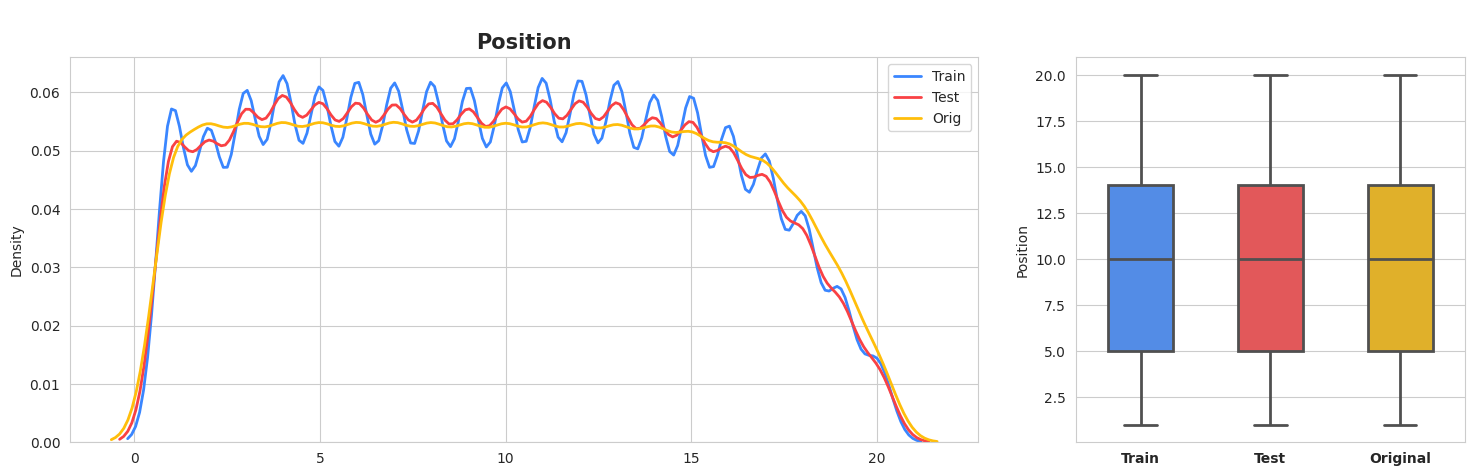

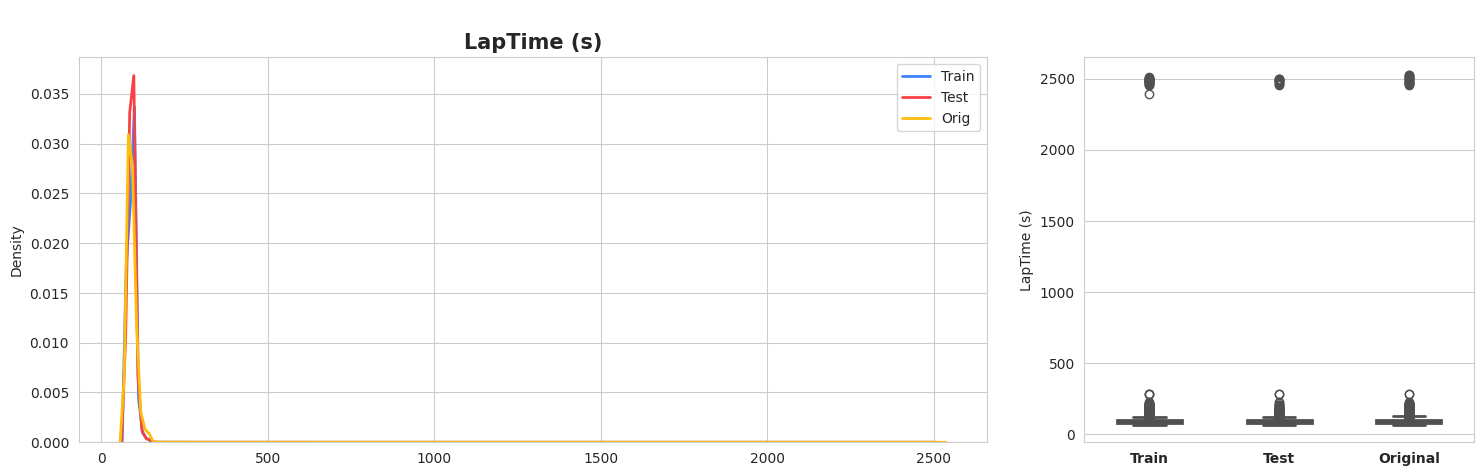

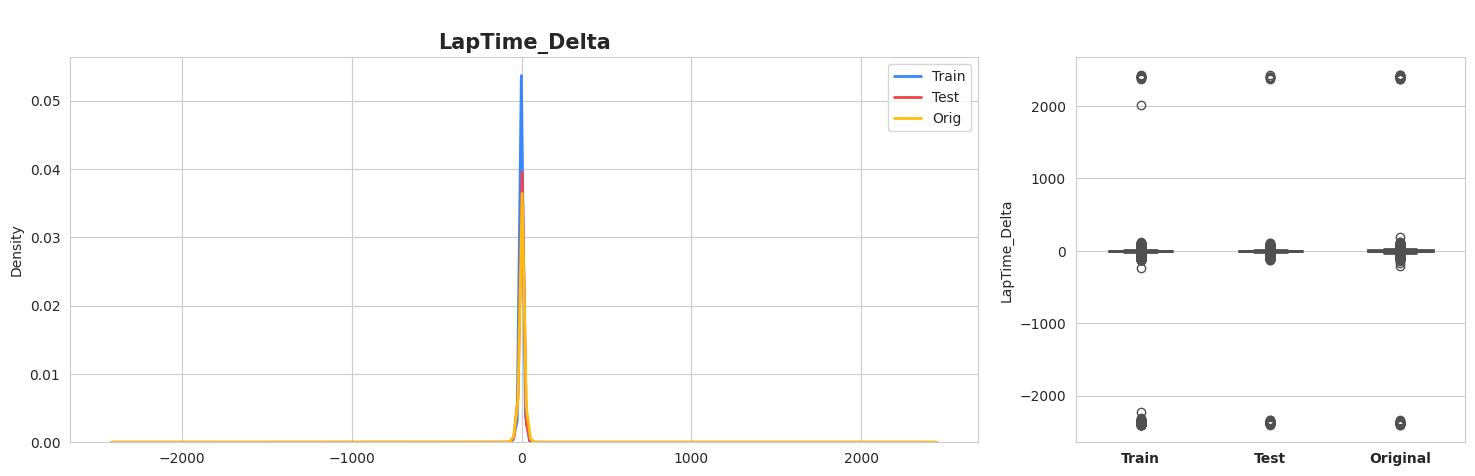

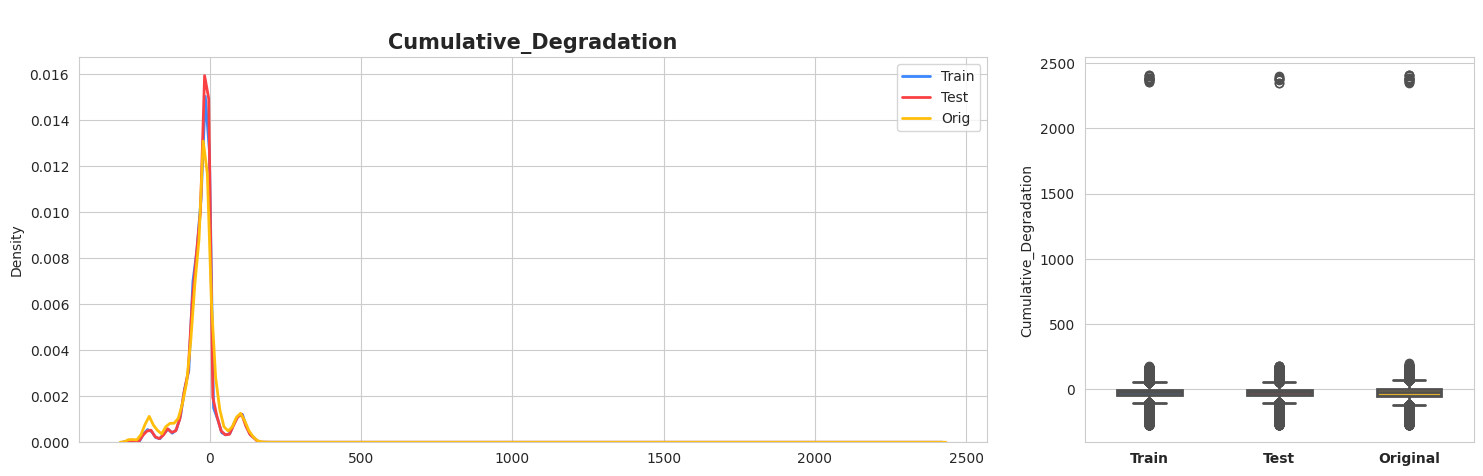

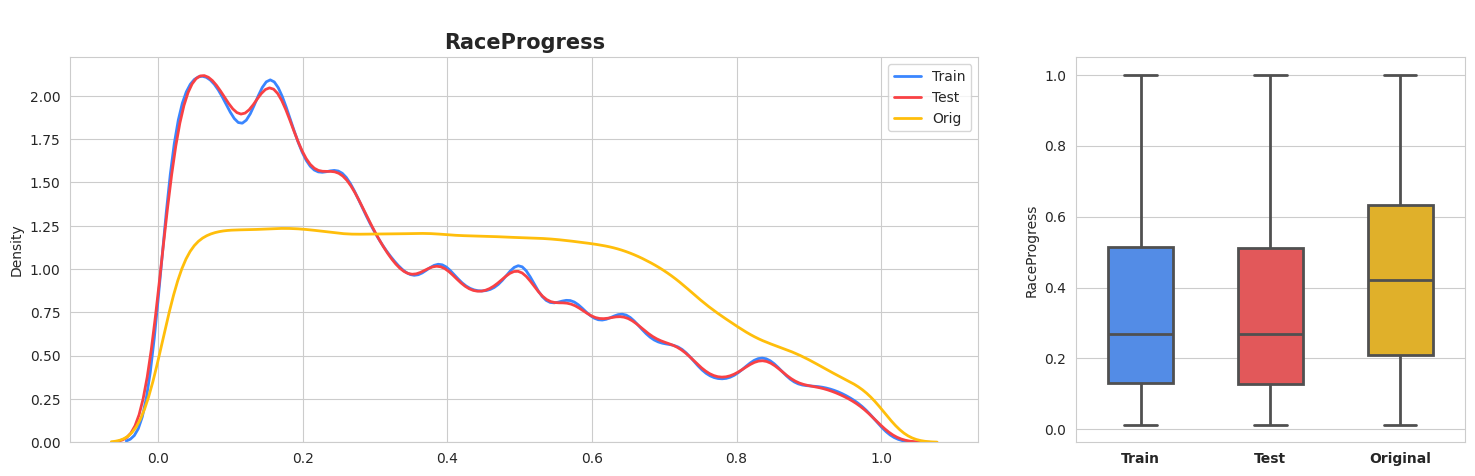

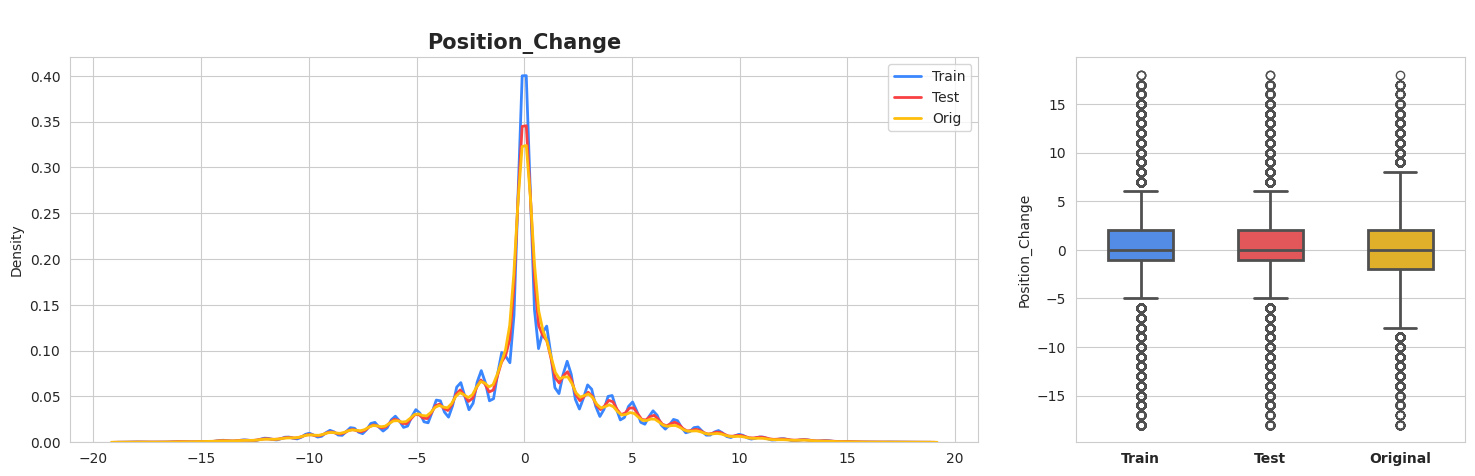

In [20]:
distplots_data(train, test, orig, NUMS)

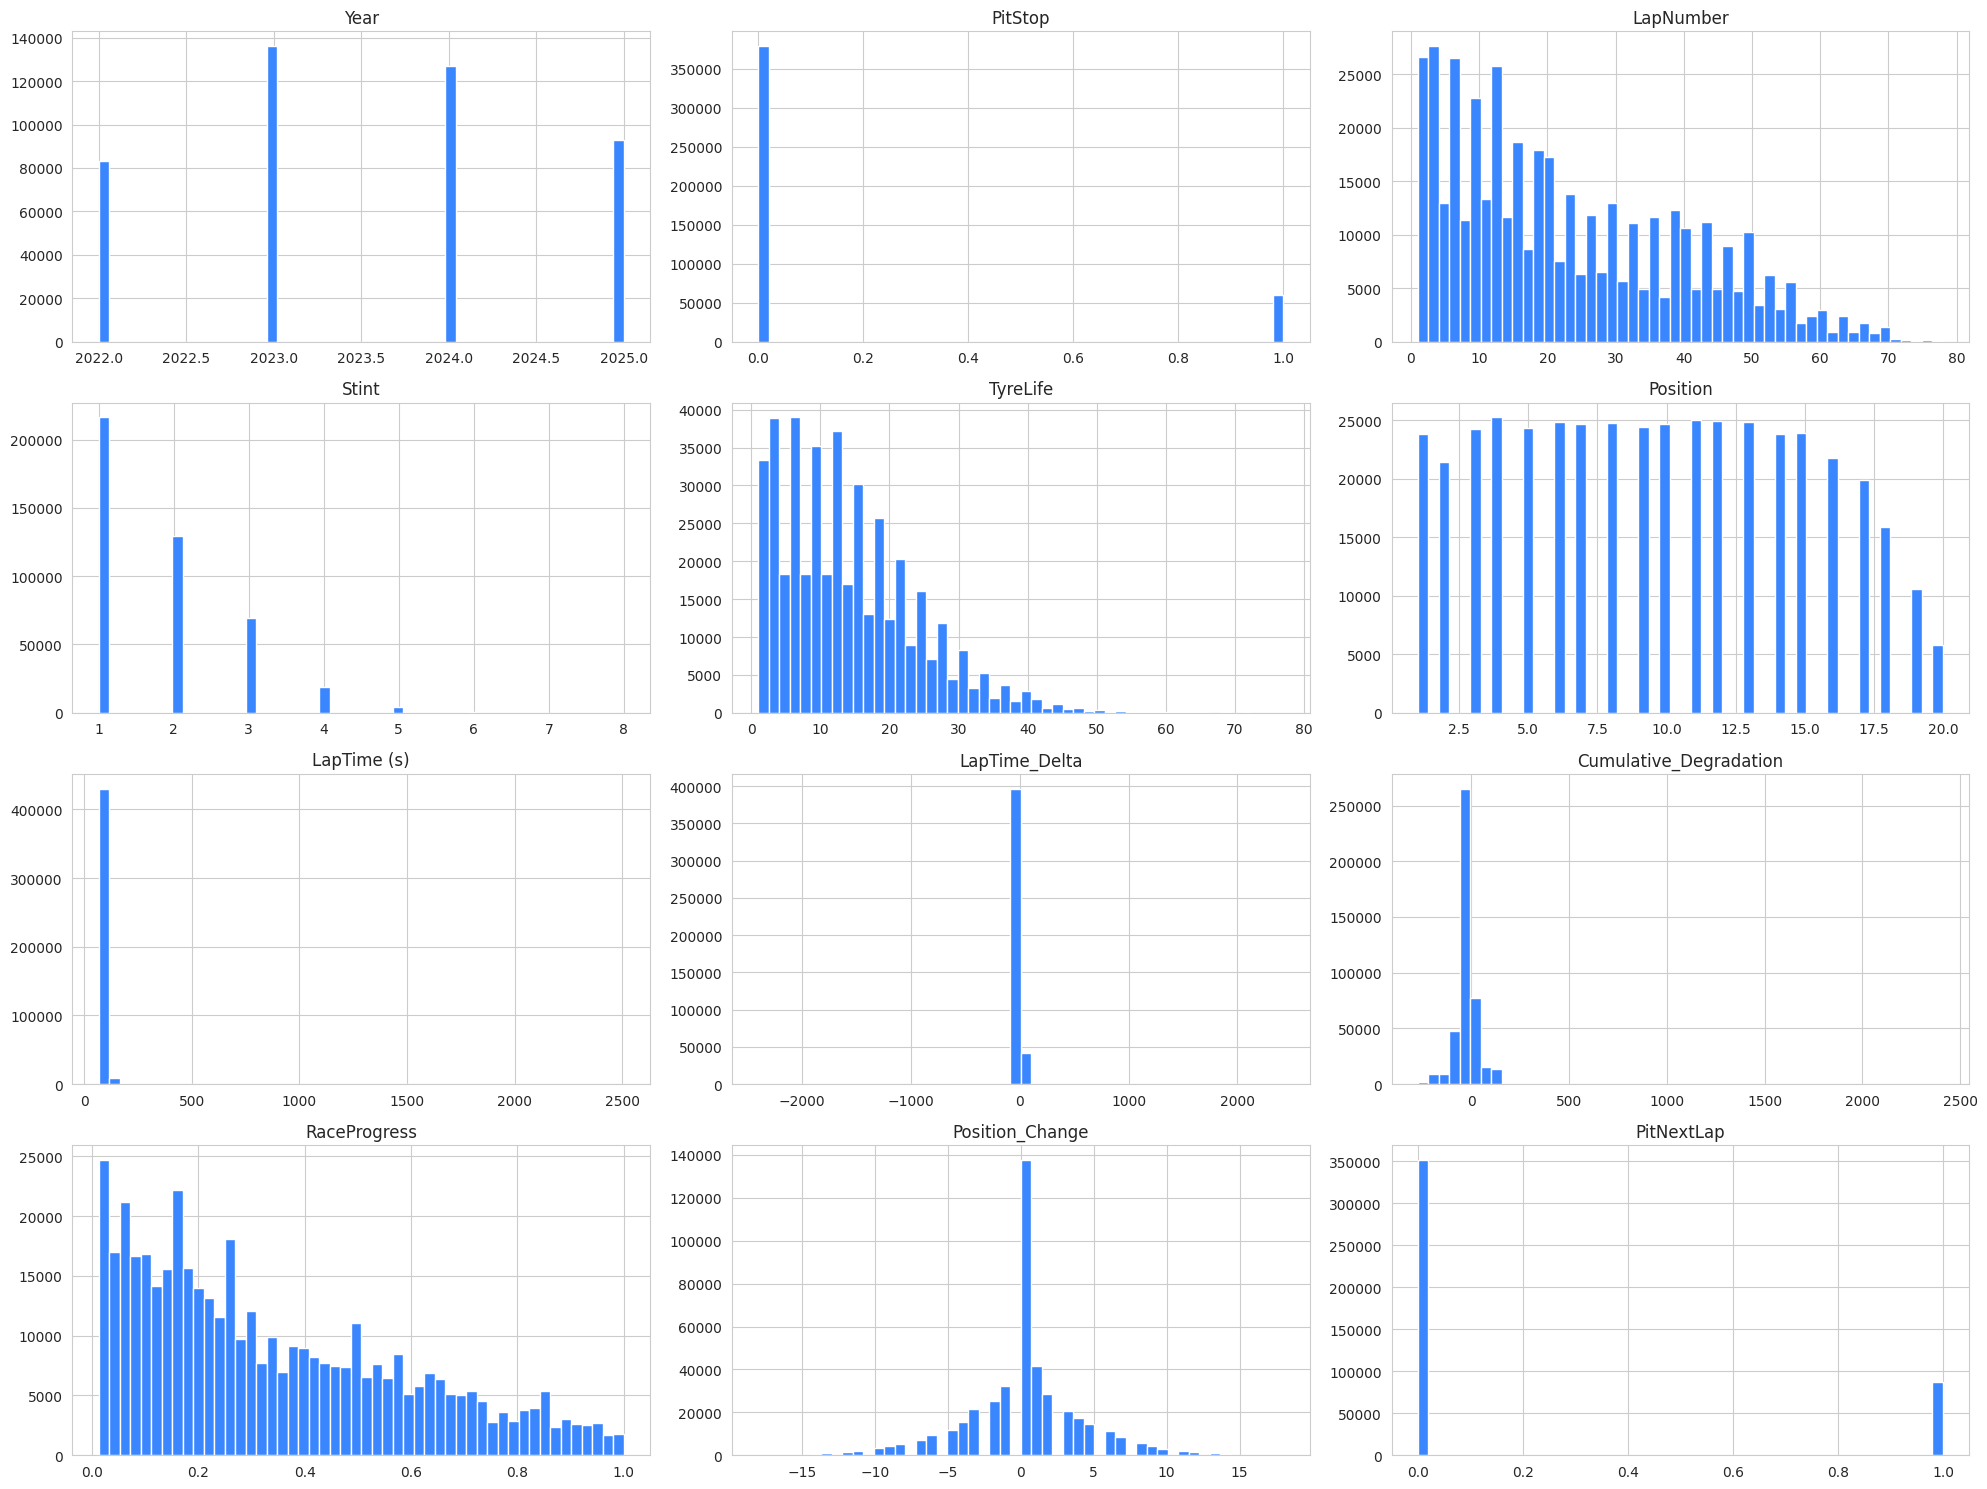

In [21]:
train.hist(figsize=(20, 15), bins=50)
plt.tight_layout()
plt.show()

## ~ CATEGORICAL

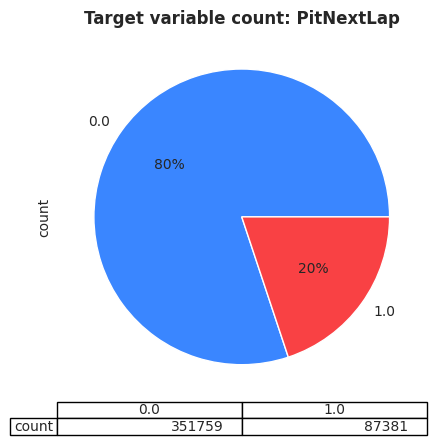

In [22]:
## -- TARGET COUNTS --
train[TARGET].value_counts(dropna=False).plot.pie(autopct='%1.0f%%', table=True)
plt.title(f"Target variable count: {TARGET}", fontweight='semibold')
plt.show()

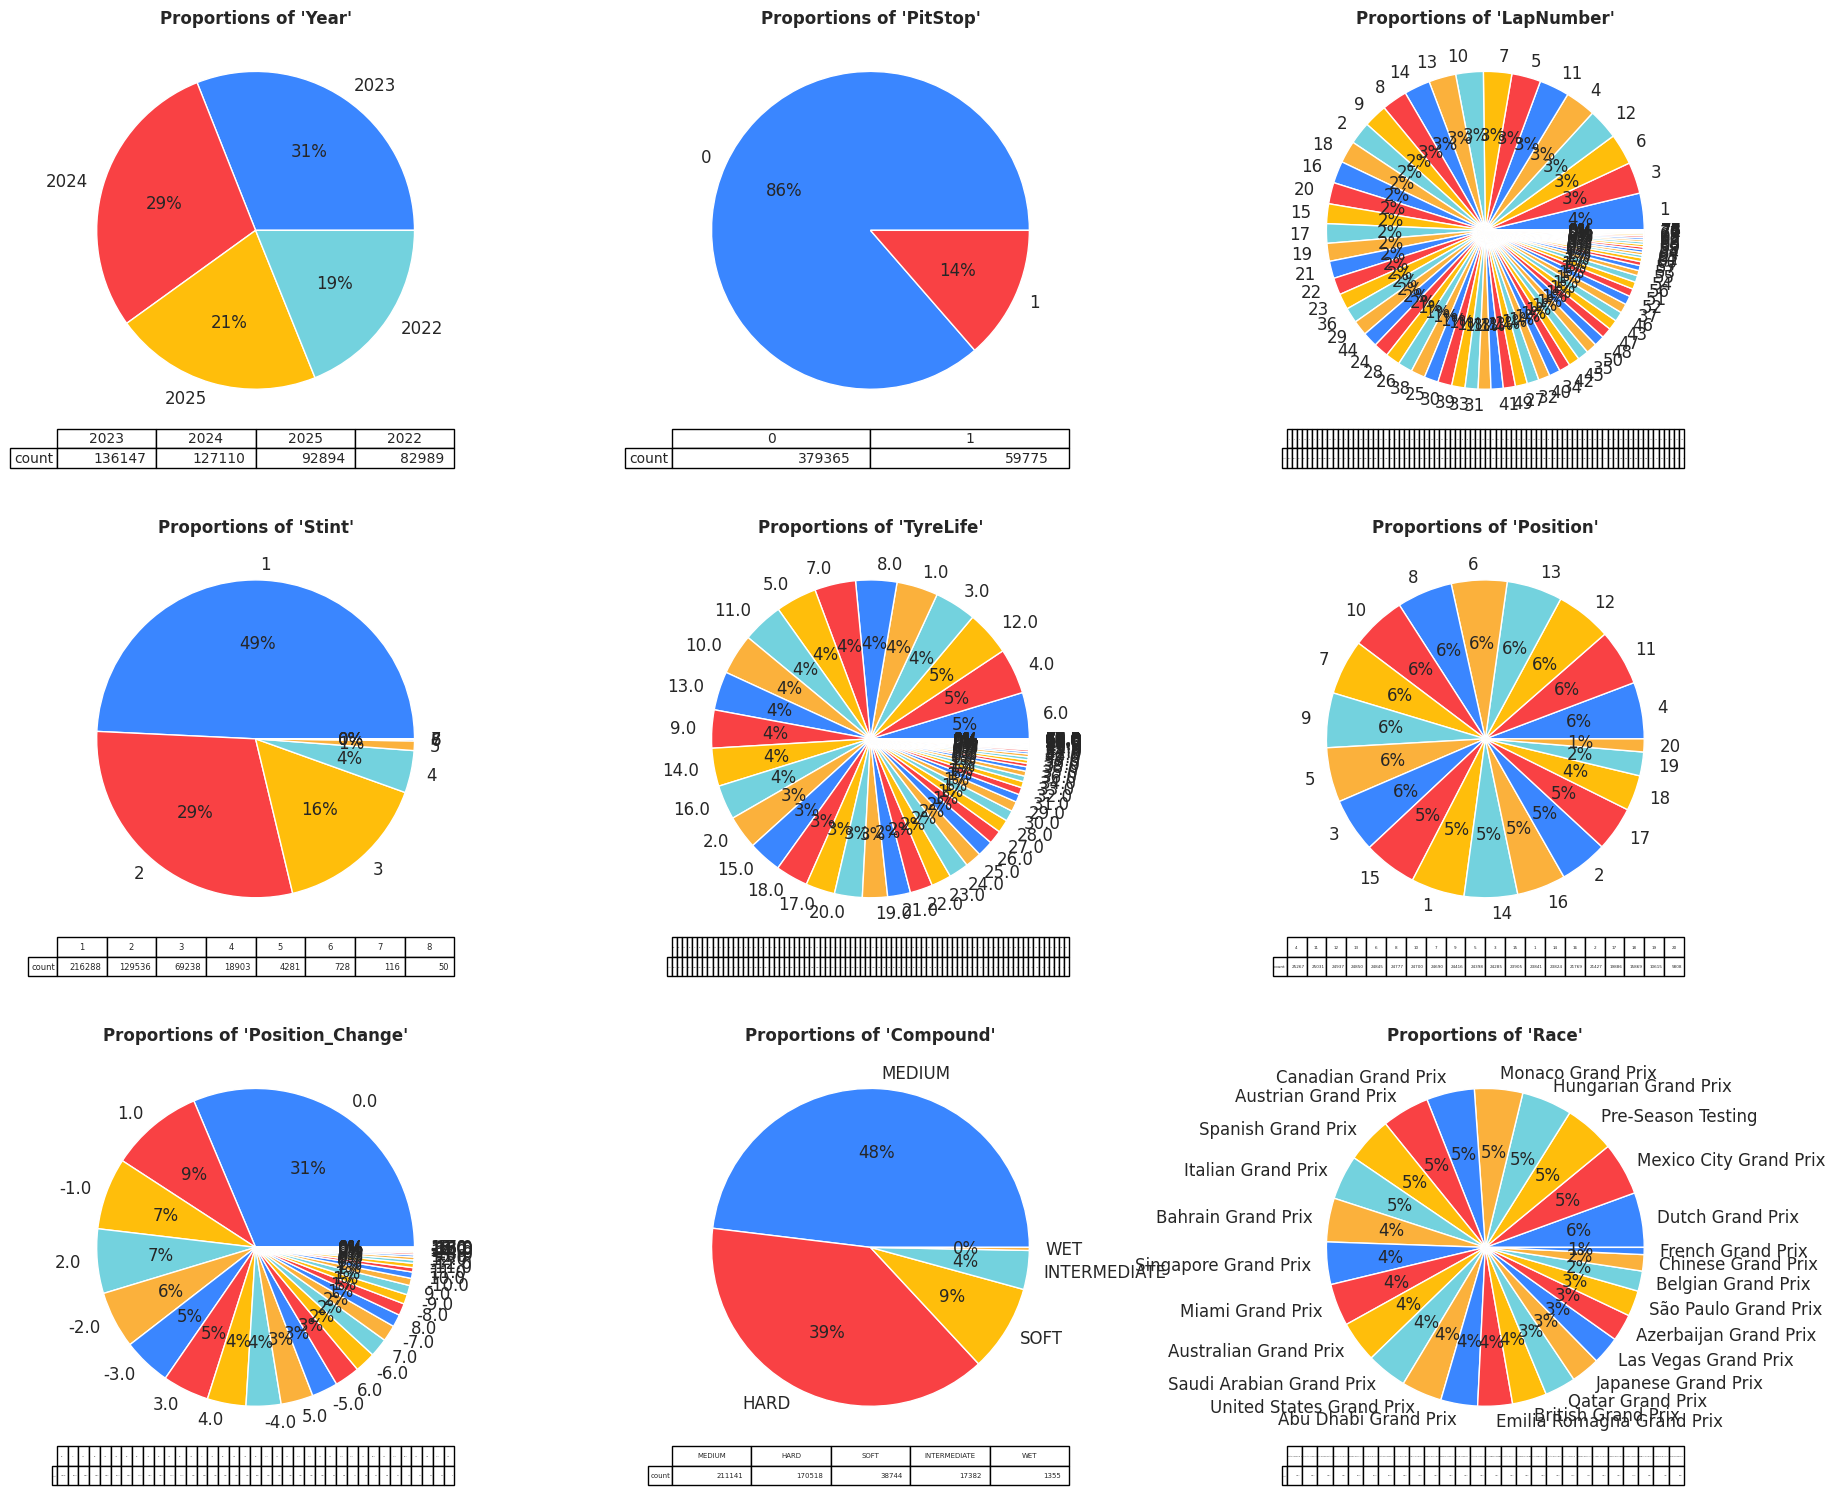

In [23]:
## -- Categorical Features --
plt.figure(figsize=(18, 15))
for i, col in enumerate([c for c in BASE if train[c].nunique() <= 100]):
    plt.subplot(3, 3, i+1)
    values=train[col].value_counts(dropna=False)
    values.plot.pie(autopct='%1.0f%%', fontsize=12, table=True)
    plt.title(f"Proportions of '{col}'", fontdict={'size':12, 'weight': 'bold'})
    plt.axis('off')

plt.tight_layout(h_pad=4.0, w_pad=1.0)
plt.show()

In [24]:
# BINS = 10

# for c in ['RaceProgress']: # 'Driver', 'LapTime (s)', 'LapTime_Delta',	'Cumulative_Degradation', 'RaceProgress'
#     # PLOT TRAIN DISTRIBUTION COMPARED WITH TEST DISTRIBUTION
#     plt.figure(figsize=(18, 5))
#     plt.subplot(121)
#     sns.histplot(train[c], kde=True, bins=50, label='train')
#     sns.histplot(test[c], kde=True, bins=50, label='test')
#     plt.legend()
#     plt.title(f"{c}")
#     # plt.xticks('')
#     # PLOT TARGET RELATIONSHIP WITH BINNED BASE
#     plt.subplot(122)
#     train['bucket'], edges = pd.cut(train[c],bins=BINS,include_lowest=True,retbins=True,labels=False)
#     bucket_means = train.groupby('bucket')[TARGET].mean()
#     bin_midpoints = (edges[:-1] + edges[1:]) / 2
#     plt.plot(bin_midpoints, bucket_means, marker='o',linestyle='-.',color='k')
#     plt.xlabel(f'{c} (Binned)')
#     plt.ylabel(f"Mean '{TARGET}'")
#     plt.title(f"Mean {TARGET} per '{c}' (train)")
#     plt.xticks(bin_midpoints, rotation=45)

#     plt.tight_layout()
#     plt.show()

# train.drop(['bucket'], axis=1, inplace=True)

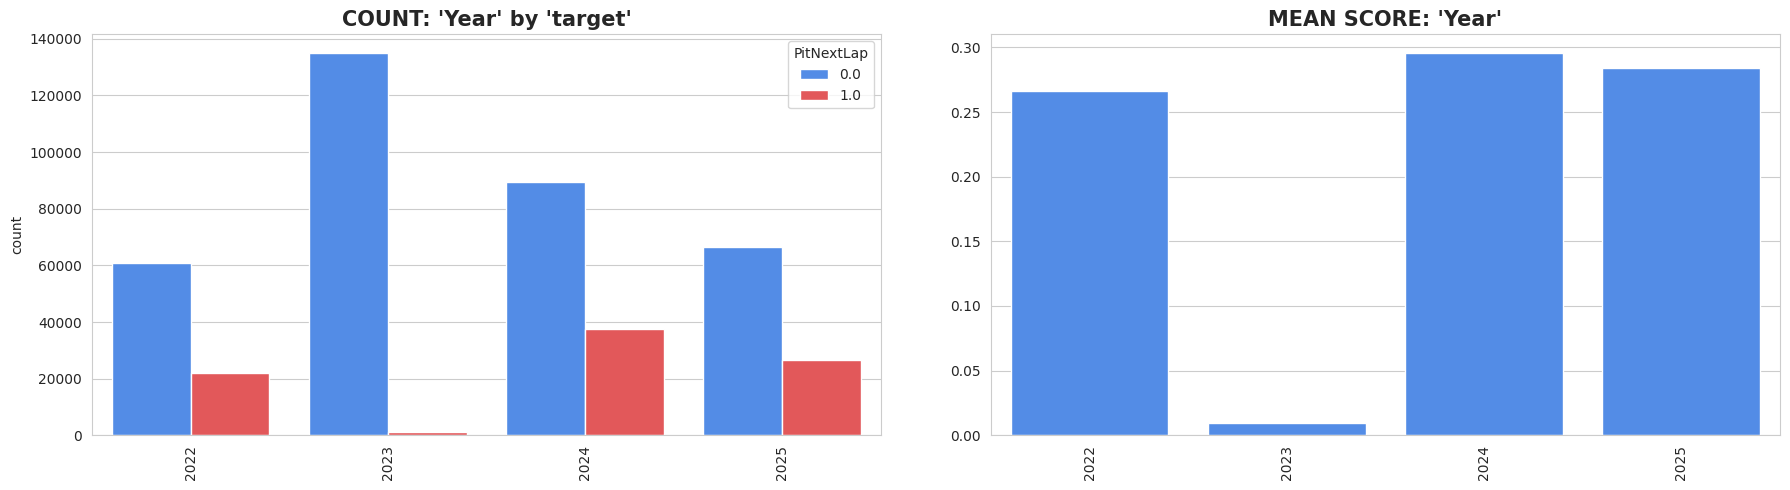

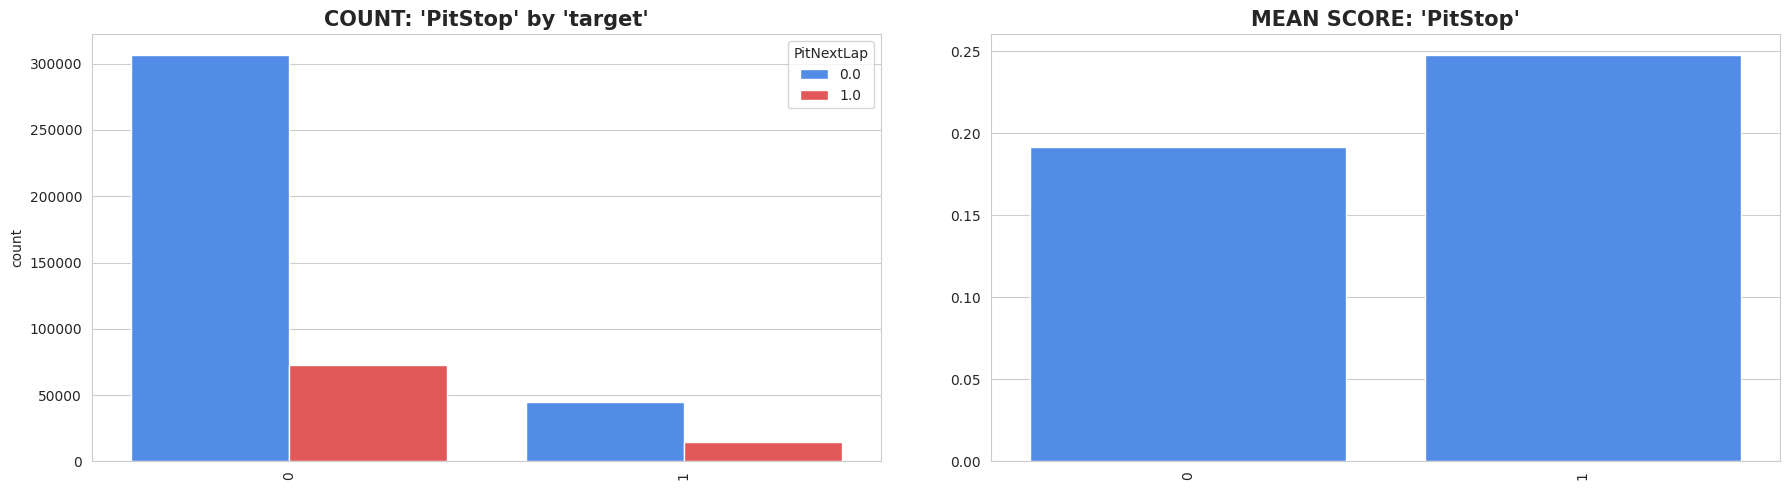

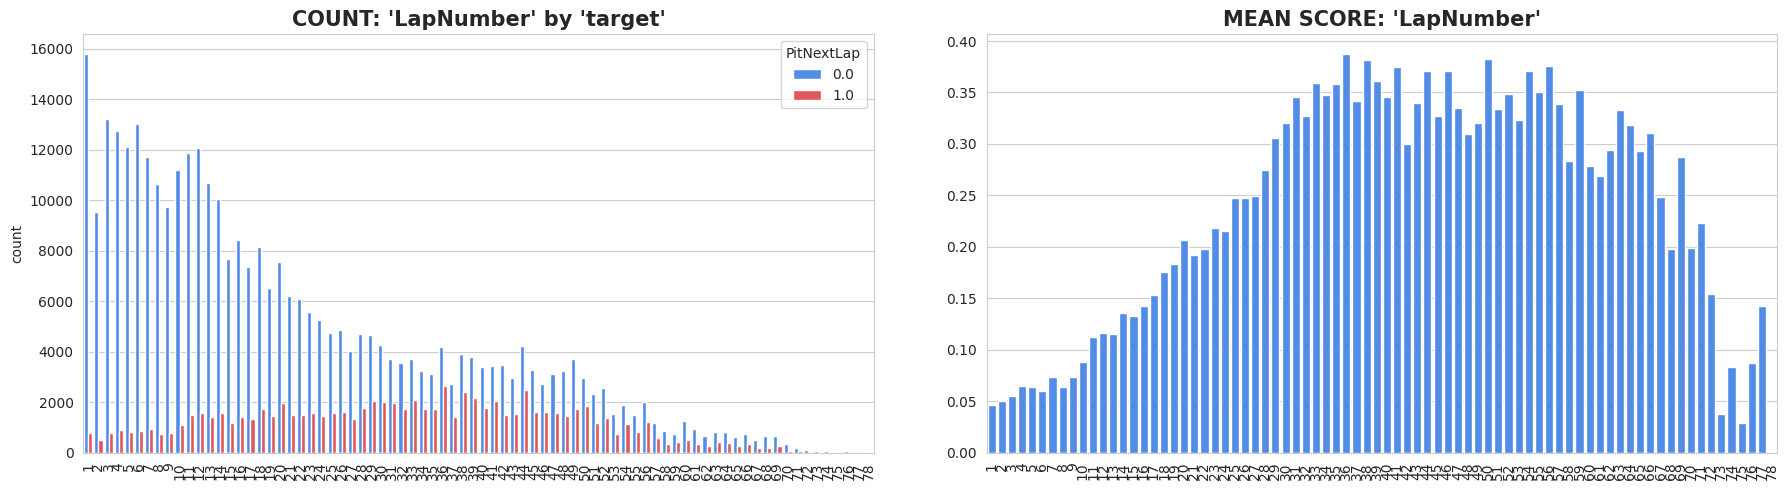

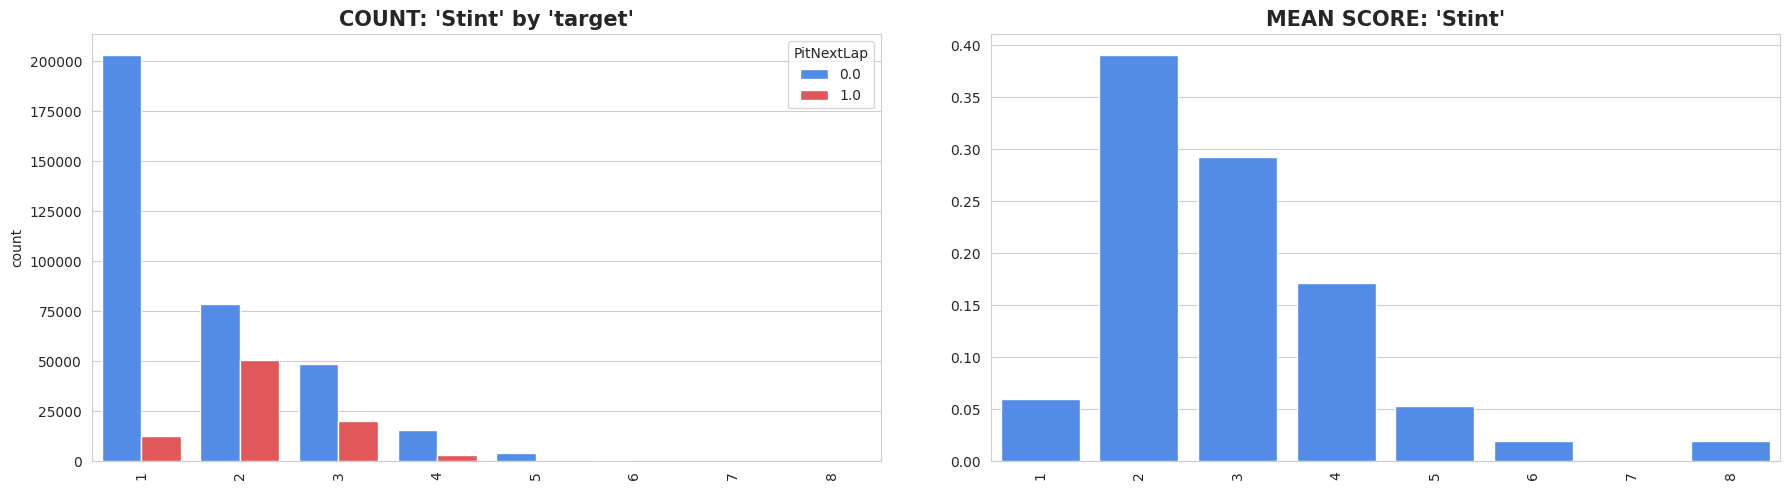

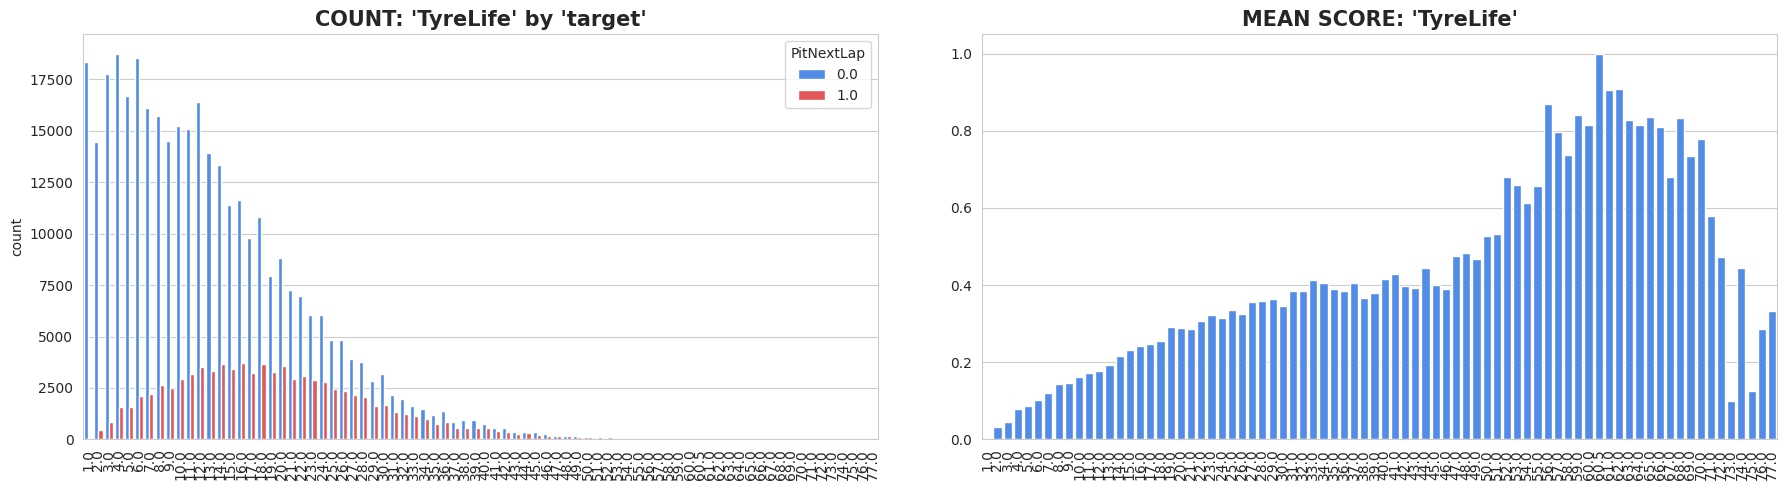

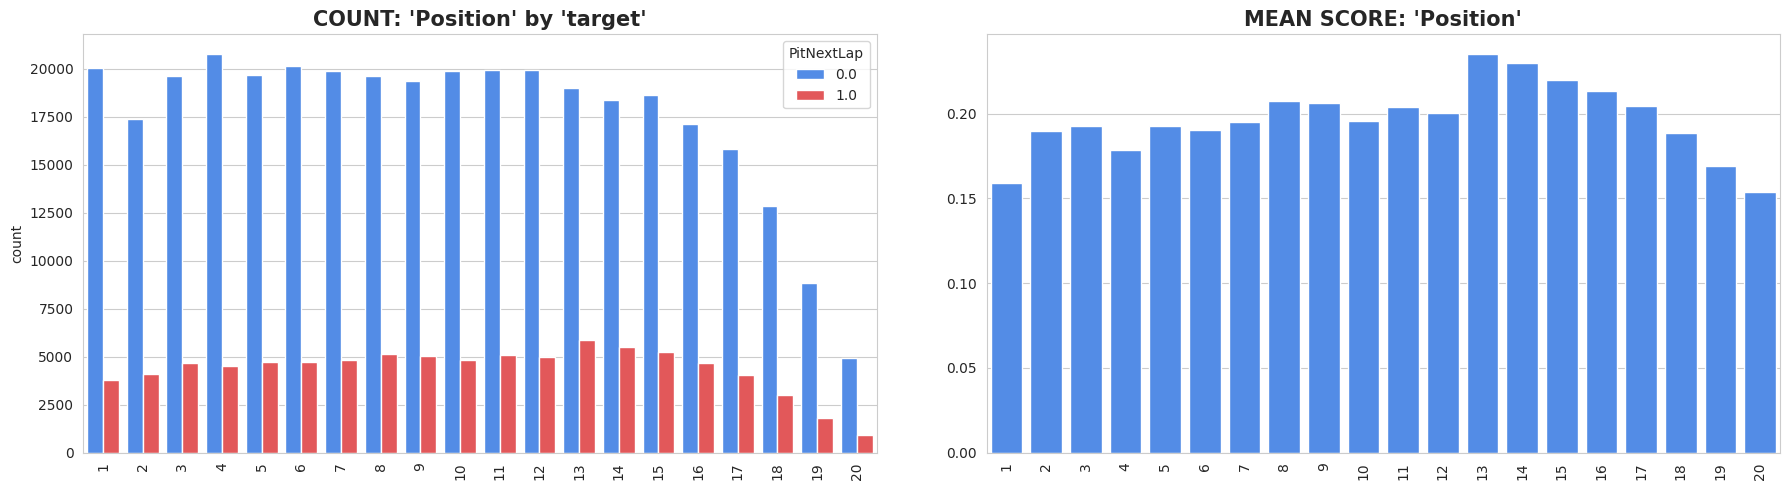

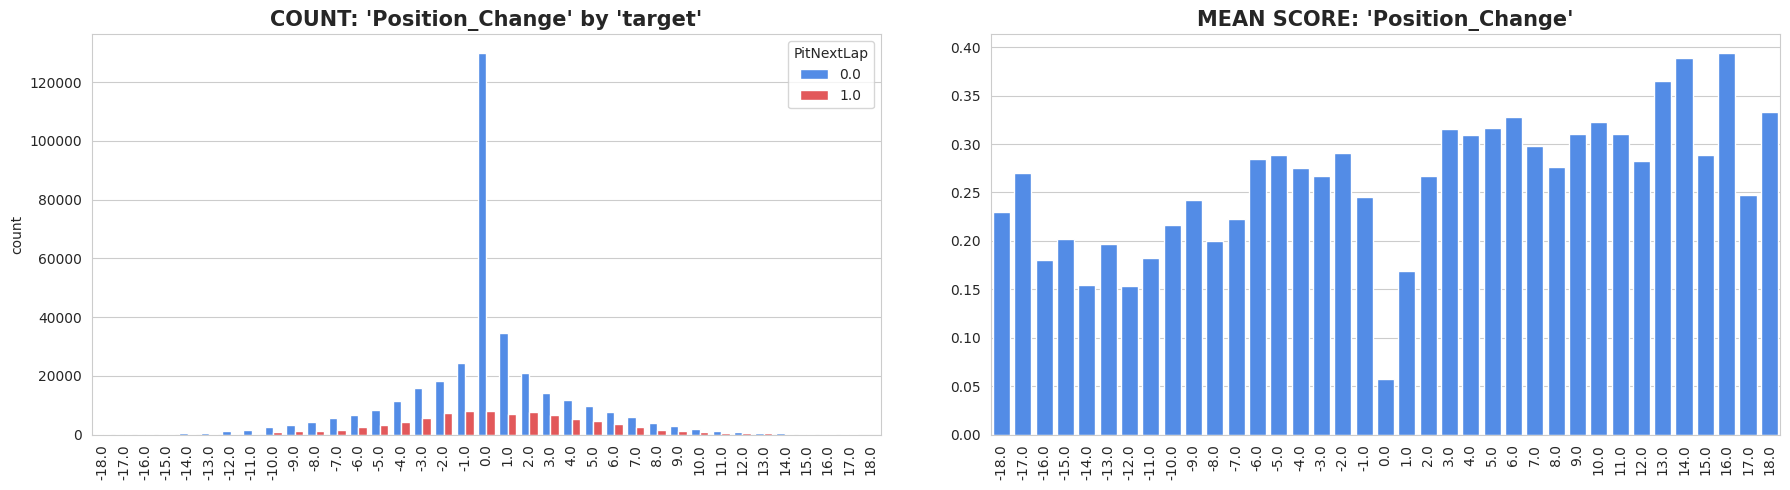

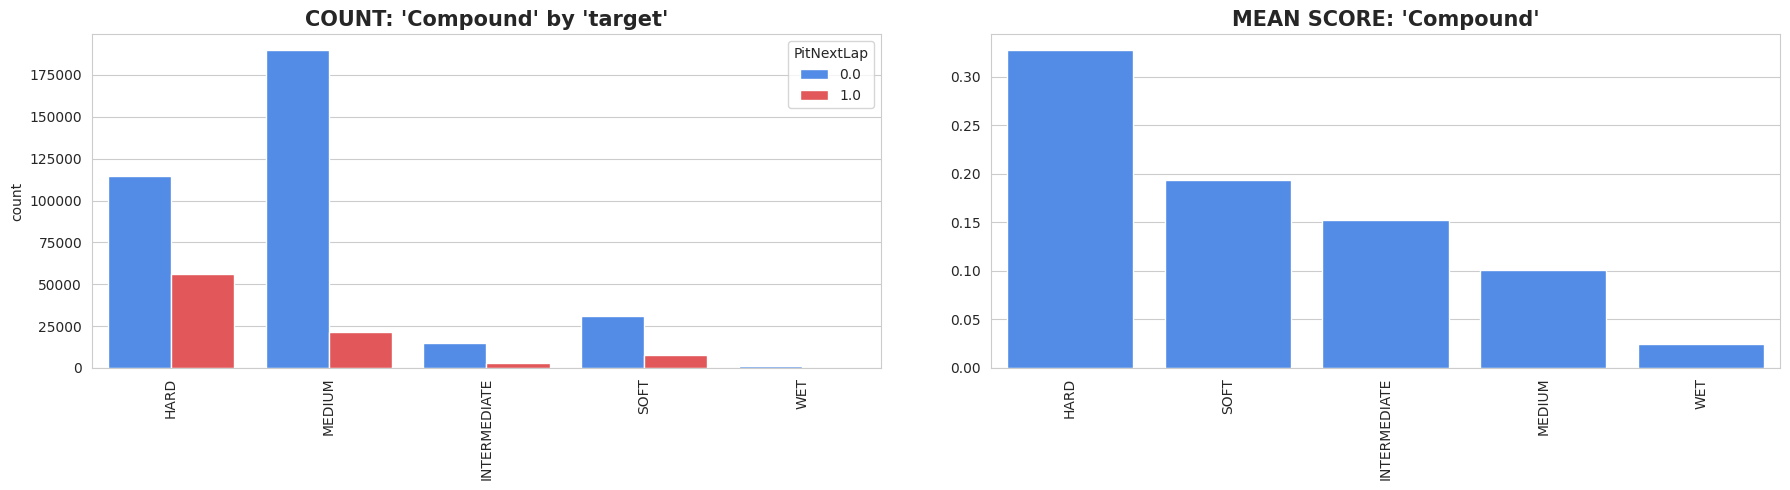

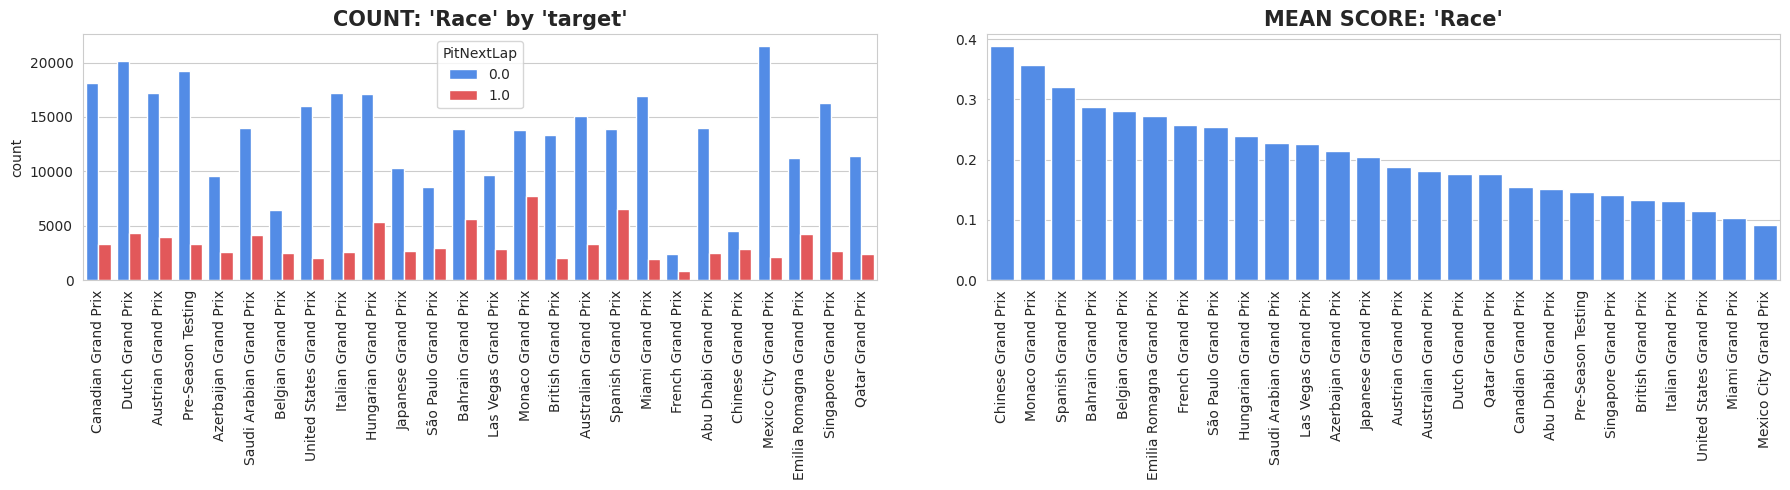

In [25]:
## -- Categorical Features: Counts and Mean by TARGET --
## -- Features with unique count <= 100
CATS_100 = [c for c in BASE if train[c].nunique() <= 100]

for i, c in enumerate(CATS_100):
    fig, axs = plt.subplots(1, 2, figsize=(18, 5))

    sns.countplot(train, x=c, hue=TARGET, ax=axs[0])
    axs[0].set_title(f"COUNT: '{c}' by 'target'", fontdict={'size': 15, 'weight': 'semibold'})
    axs[0].set_xlabel('')
    axs[0].tick_params(axis='x', rotation=90)

    v_mean = train.groupby(c)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=v_mean.index, y=v_mean.values, ax=axs[1])
    axs[1].set_title(f"MEAN SCORE: '{c}'", fontdict={'size': 15, 'weight': 'semibold'})
    axs[1].set_xlabel('')
    axs[1].tick_params(axis='x', rotation=90)

    _ = fig.tight_layout(w_pad=5.0)
    plt.show()
    print()

## ~ CATEGORICAL PAIR ANALYSIS

In [26]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

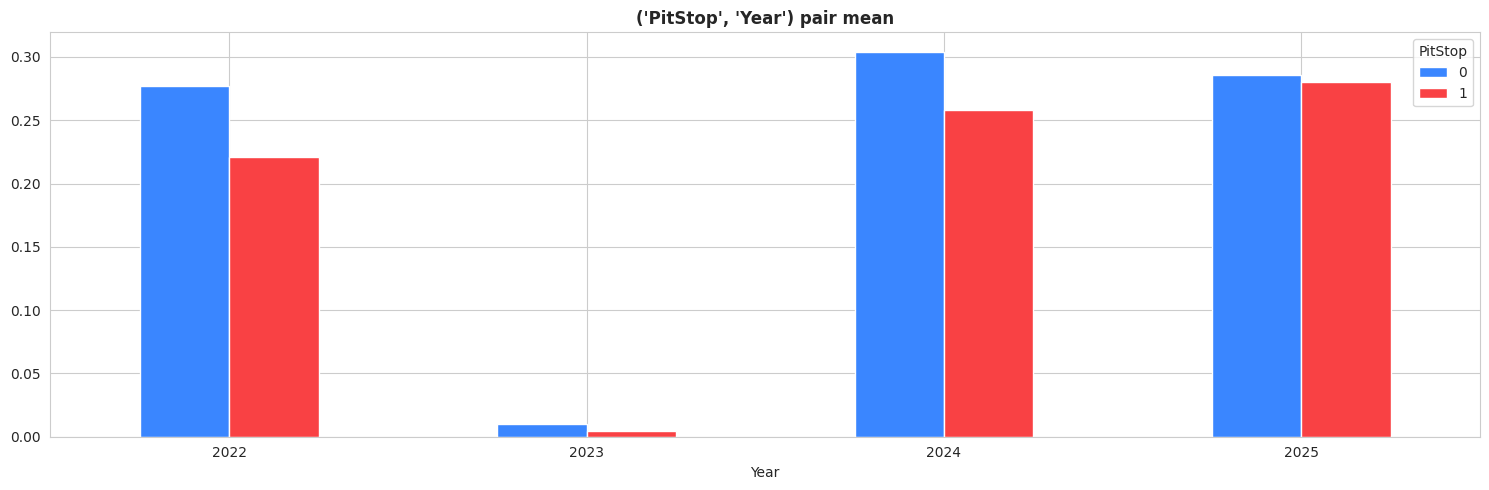

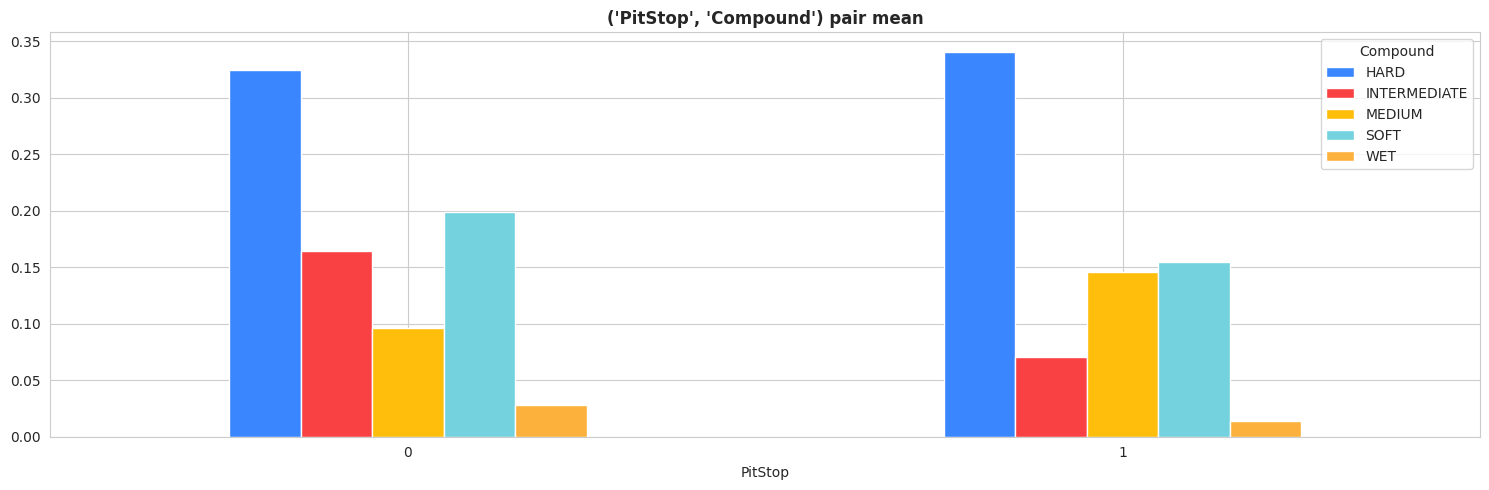

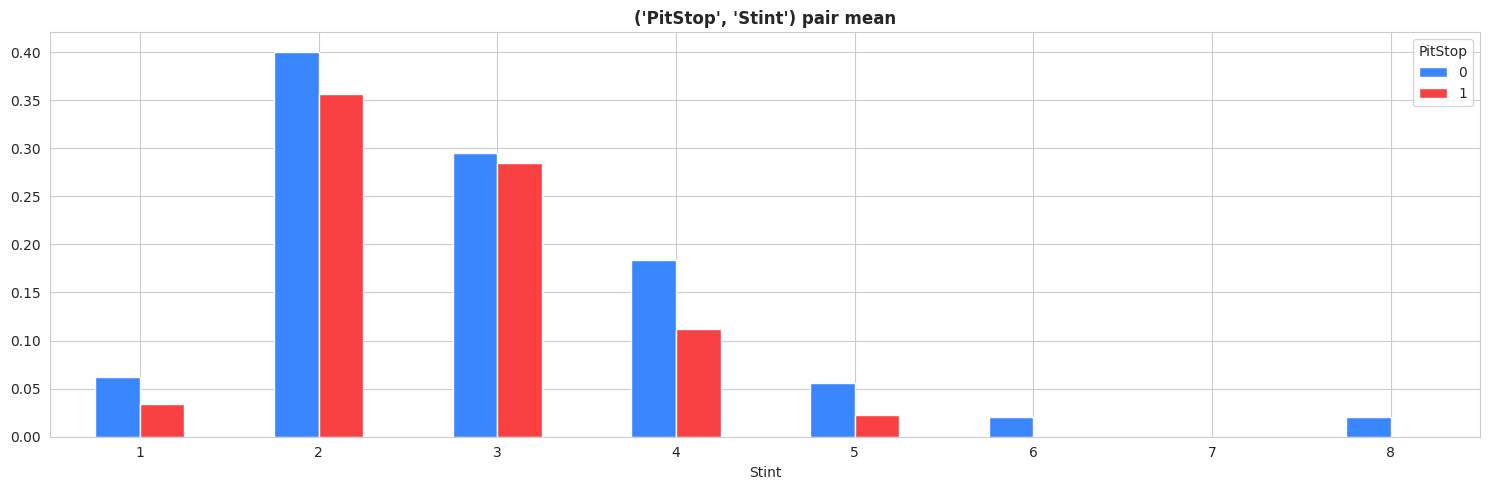

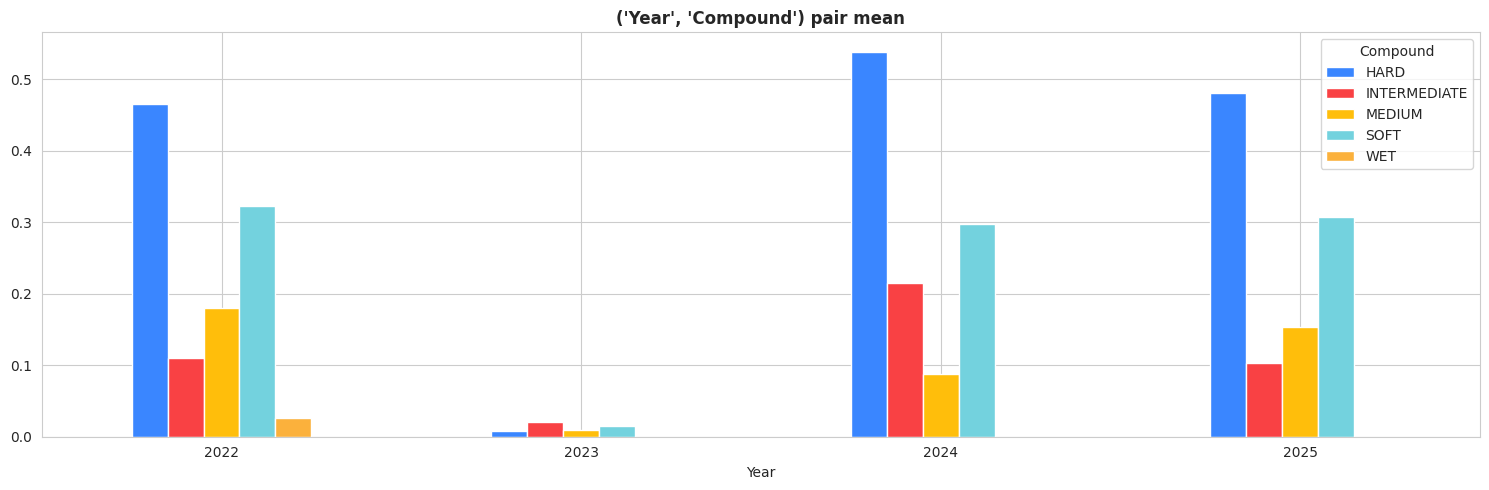

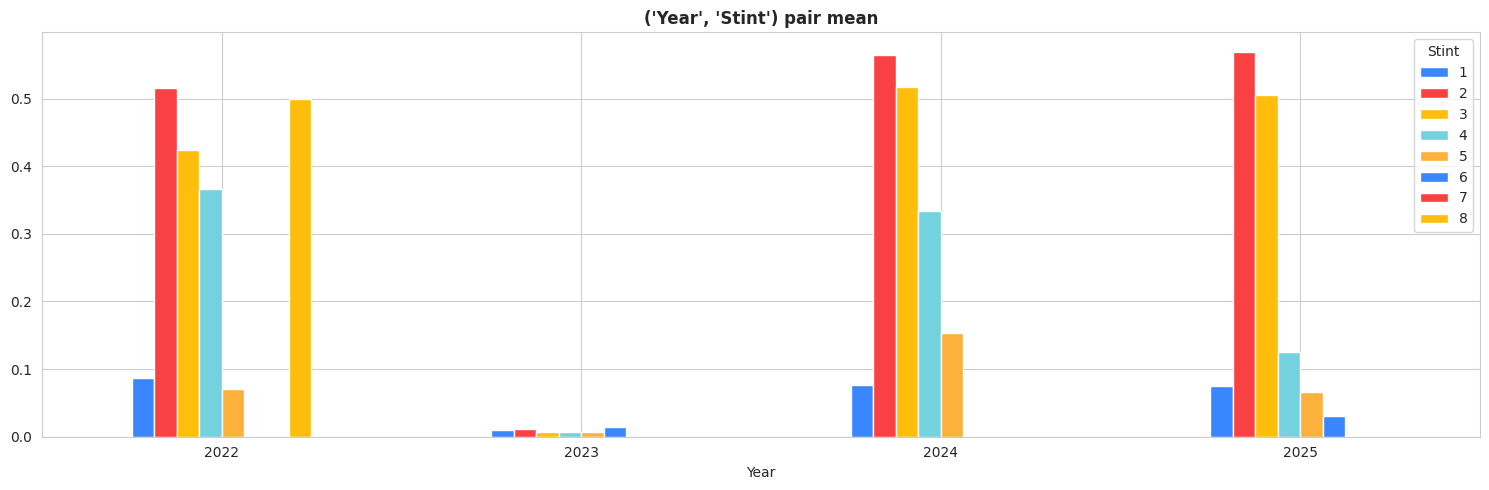

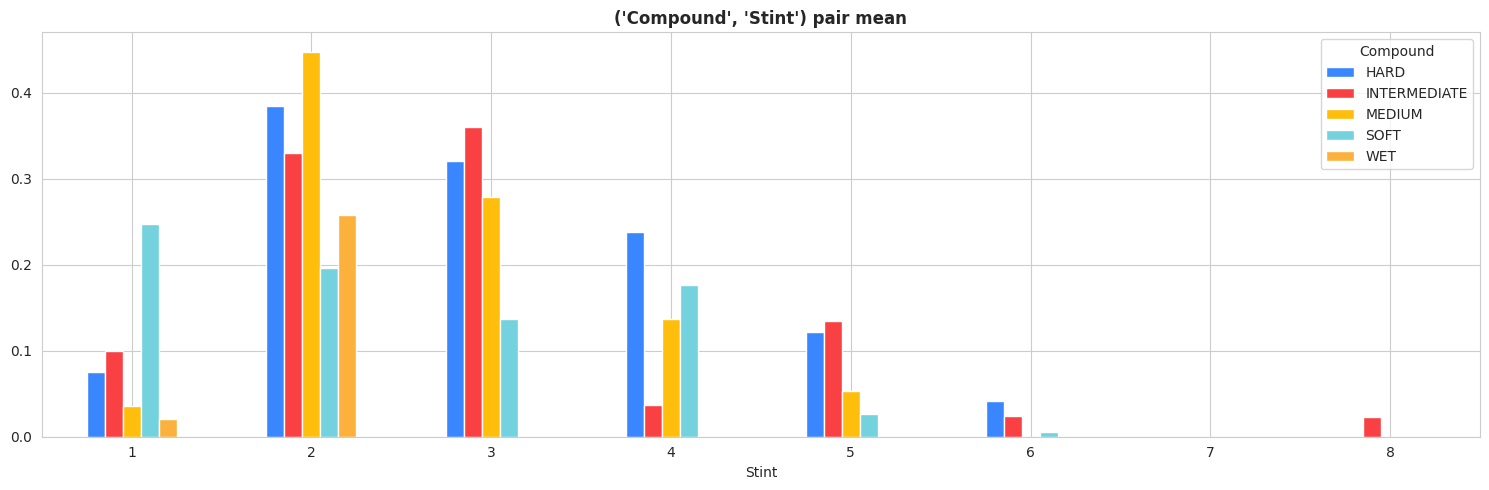

In [27]:
## -- Possible features for GroupKFold --
PAIRS = itertools.combinations(n_unique[n_unique < 10].index, 2)
# [
#     ['Year', 'Compound'], ['Year', 'Stint'], ['Compound', 'Stint'], ['Stint', 'PitStop']
# ]

for i, combo in enumerate(PAIRS):
    train.groupby(sorted([*combo], reverse=True))[TARGET].mean().unstack().plot.bar(figsize=(15, 5))
    plt.title(f'{combo} pair mean', fontweight='semibold')
    plt.tick_params('x', rotation=0)
    plt.tight_layout()
    plt.show()
    print()

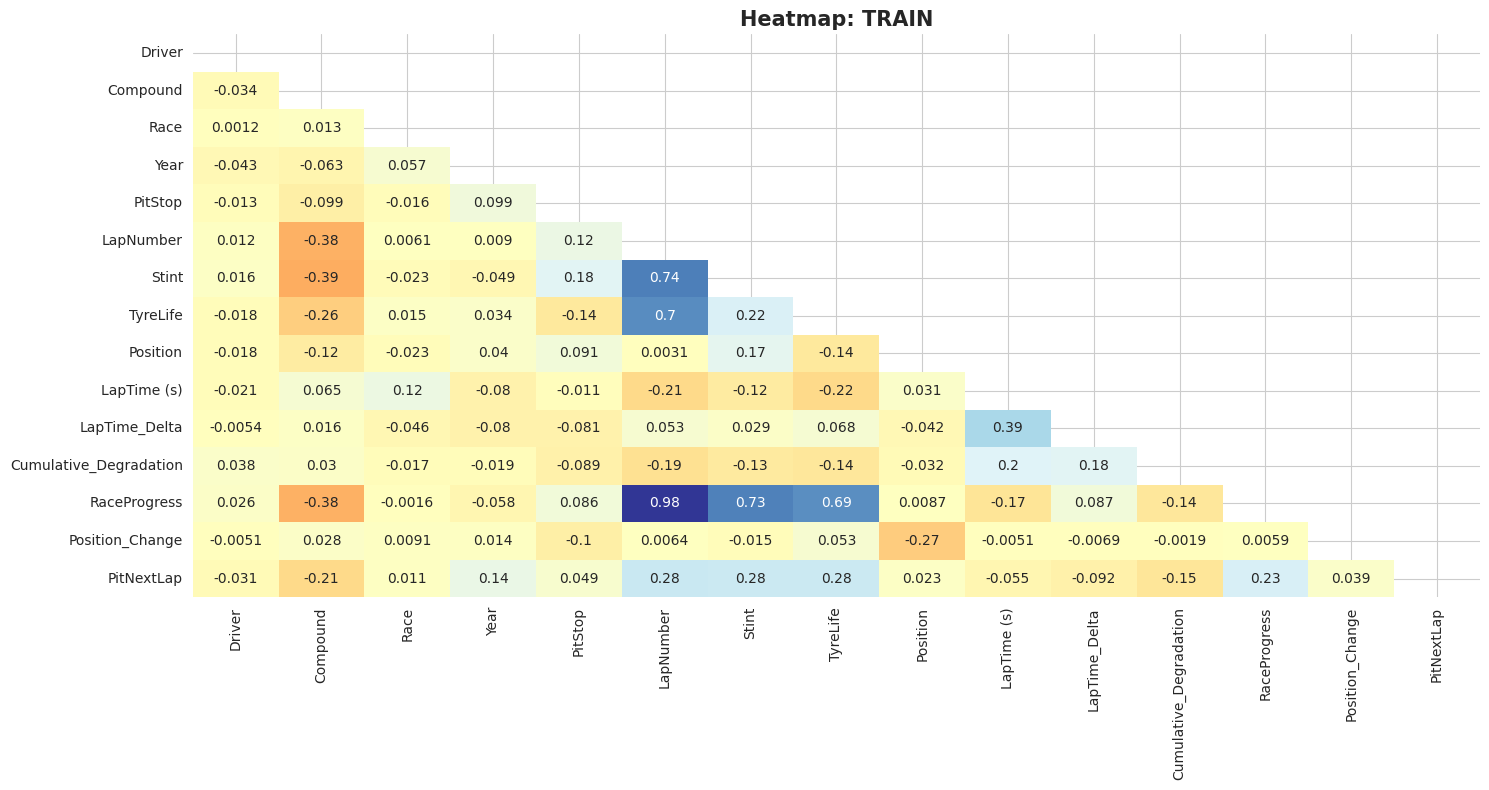

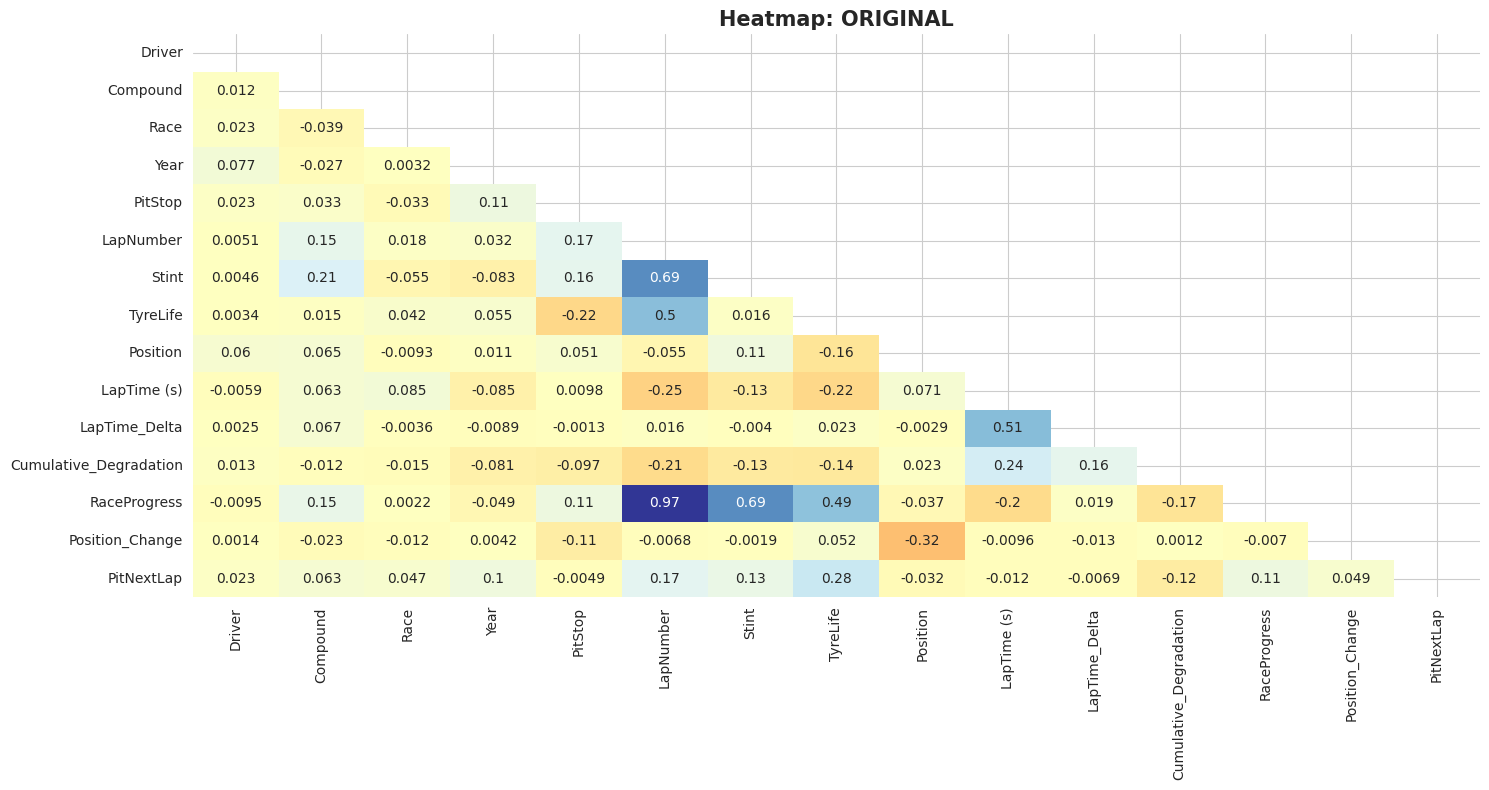

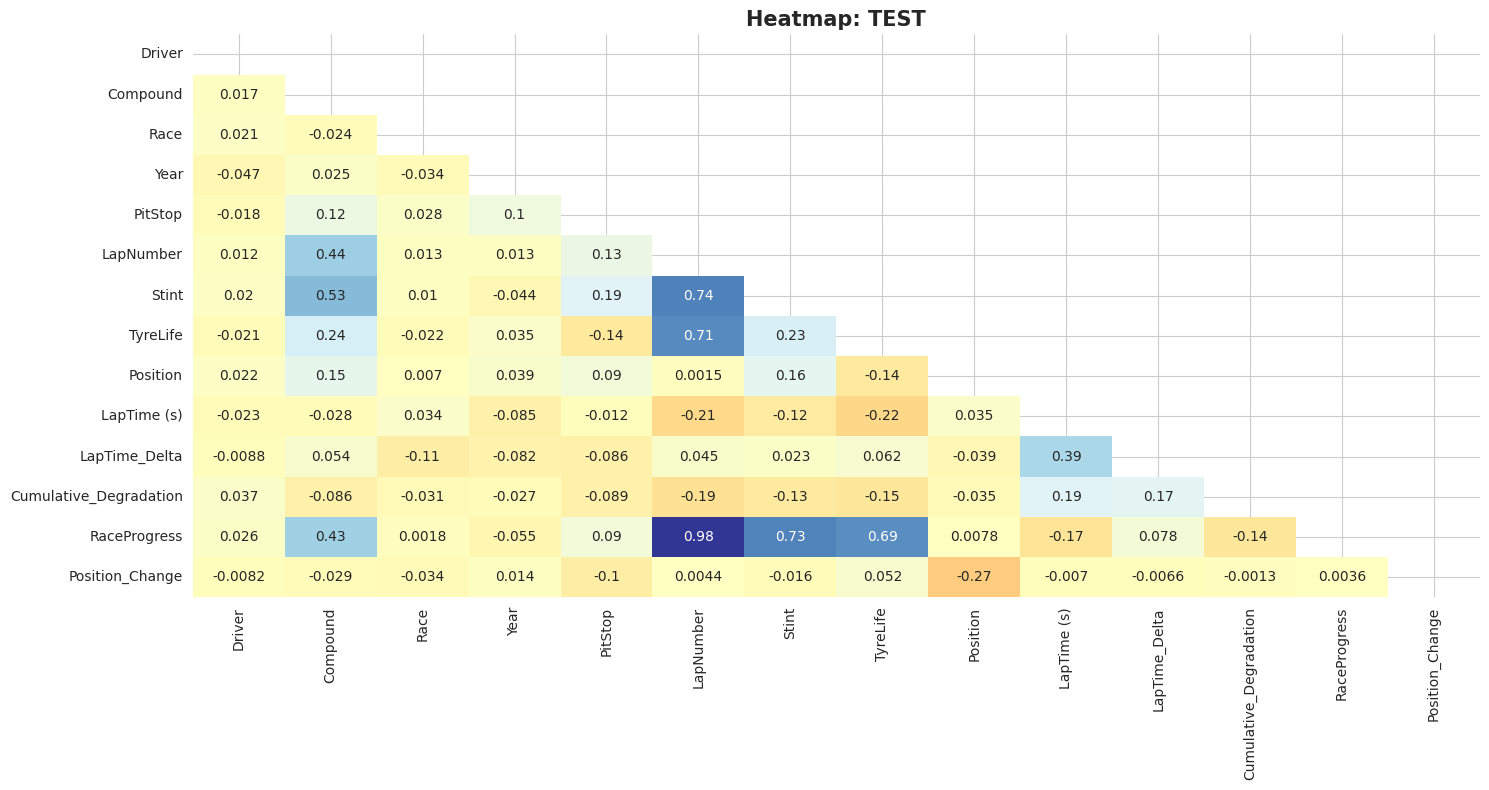

In [28]:
def plot_heatmap(df_, name='Data'):
    df = df_.copy()
    cat_cols = [c for c in df.columns if df[c].dtype in ['str', 'object', 'category']]
    for c in cat_cols:
        df[c] = pd.factorize(df[c])[0]

    CORR = df.corr('spearman')
    plt.figure(figsize=(15, 8))
    sns.heatmap(CORR, mask=np.triu(CORR), annot=True, cmap='RdYlBu', cbar=False, center=0)
    plt.title(f"Heatmap: {name}", fontdict={'size':15, 'weight': 'semibold'})
    plt.tight_layout()
    plt.show()

    del df

plot_heatmap(train, 'TRAIN')
plot_heatmap(orig, 'ORIGINAL')
plot_heatmap(test, 'TEST')

In [29]:
# ## -- VIOLIN PLOT --
# plt.figure(figsize=(18, 5))
# for i, col in enumerate(NUMS):
#     plt.subplot(1, len(NUMS), i+1)
#     sns.violinplot(train[col])

# plt.tight_layout()
# plt.show()

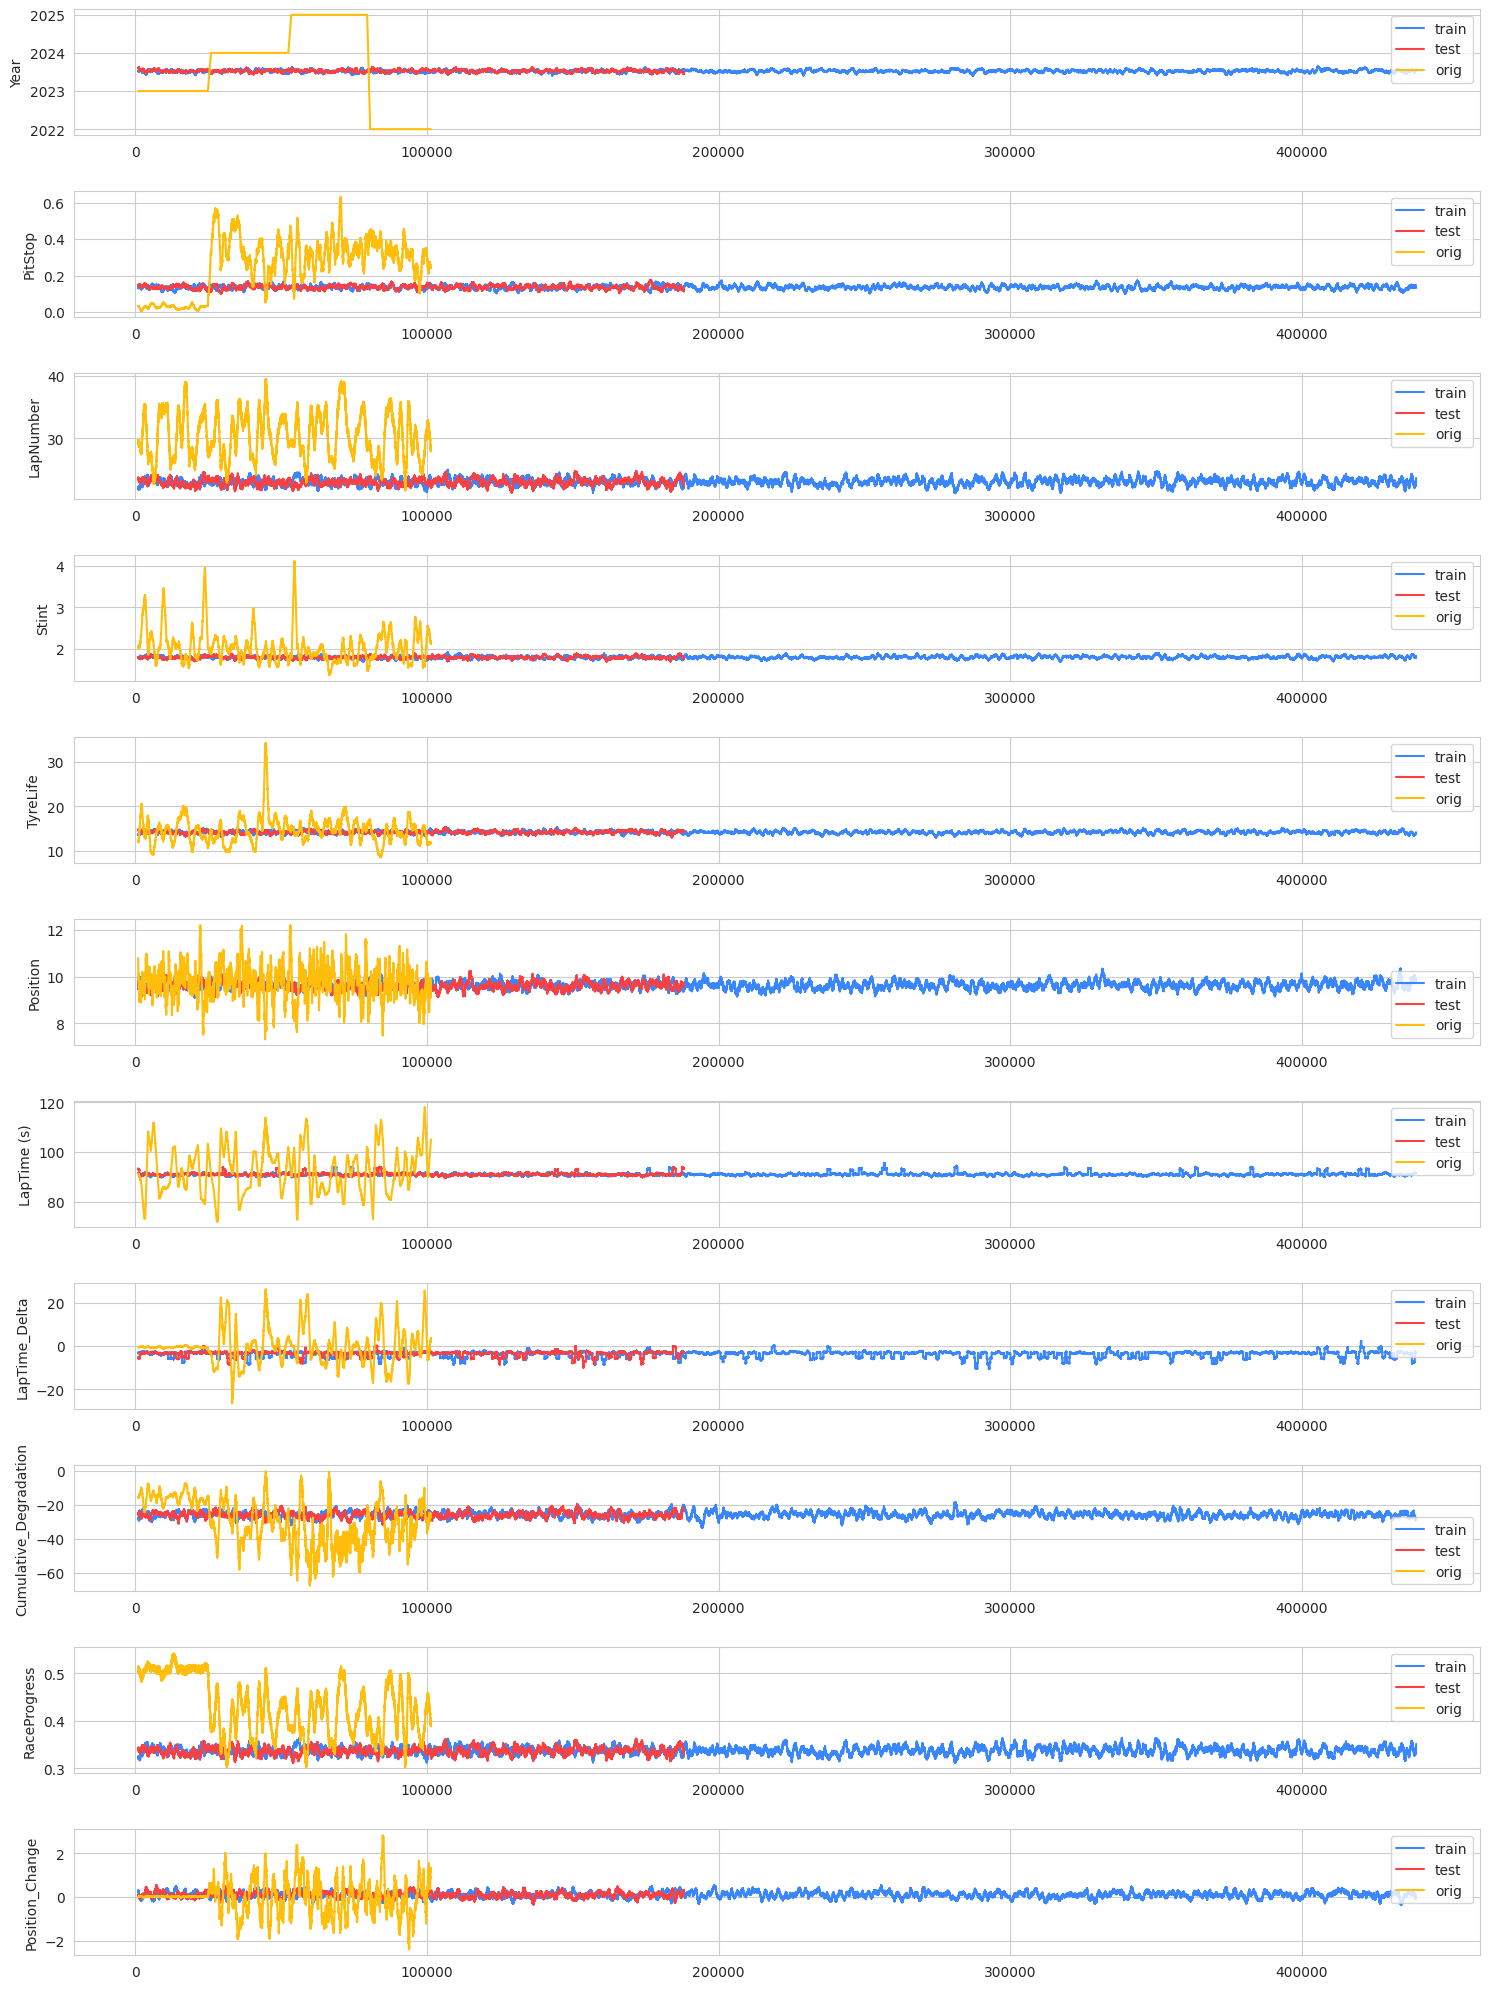

In [30]:
## -- Drift check--
# num_cols = [c for c in BASE if train[c].dtype == np.number]

plt.figure(figsize=(15, 20))
for i, col in enumerate(NUMS):
    plt.subplot(len(NUMS), 1, i+1)
    sns.lineplot(train[col].rolling(1000).mean(), label='train')
    sns.lineplot(test[col].rolling(1000).mean(),  label='test')
    sns.lineplot(orig[col].rolling(1000).mean(),  label='orig')

plt.legend()
plt.tight_layout(h_pad=2)
plt.show()

In [31]:
# %%time

# ## -- FEATURE MUTUAL INFO --
# mutual_info = mutual_info_regression(train[BASE], train[TARGET])
# mutual_info_df = pd.DataFrame.from_dict(
#     dict(zip(test.columns.tolist(), list(mutual_info))),
#     orient='index', columns=['Score'],
# ).sort_values(by='Score', ascending=False)

# plt.figure(figsize=(18, 8))
# sns.barplot(data=mutual_info_df, x='Score', y=mutual_info_df.index)
# plt.title('-- Univariate Analysis: Top predictors --')
# plt.show()

## 1. Kolmogorov-Smirnov (K-S) test

In [32]:
from scipy.stats import ks_2samp

def ks_driftcheck(df_1, df_2, df2_mame: str, features):
    df_train = df_1.copy()
    df_test  = df_2.copy()

    ks_stats_all = []
    cols = []
    threshold = 0.05

    print(f"{'feature':<20}\t{'ks-stat':<8}\t{'drift'}")
    print(f"{'-'*20:<20}\t{'-------':<8}\t{'-------'}")
    RED = '\033[33m'
    for c in features:
        ks_stat, p_val = np.round(ks_2samp(df_train[c].values, df_test[c].values), 4)
        if ks_stat >= threshold:
            print(f"{CFG.YELLOW}{c:<20}\t{ks_stat:<8}\t⚠️ Drift{CFG.RESET}")
        else:
            print(f"{c:<20}\t{ks_stat:<8}\t✅ Safe!")

        ks_stats_all.append(ks_stat)
        cols.append(c)

    print()
    plt.barh(cols, ks_stats_all, color=['r' if c >= threshold else 'gray'for c in ks_stats_all])
    plt.axvline(x=threshold, linestyle='--', label=f'Drift threshold: {threshold}')
    plt.title(f"(K-S) drift test: TRAIN vs {df2_mame}", fontweight='semibold')
    plt.legend()
    plt.show()

    gc.collect()


feature             	ks-stat 	drift
--------------------	------- 	-------
Year                	0.0021  	✅ Safe!
PitStop             	0.0001  	✅ Safe!
LapNumber           	0.0032  	✅ Safe!
Stint               	0.0027  	✅ Safe!
TyreLife            	0.0029  	✅ Safe!
Position            	0.0024  	✅ Safe!
LapTime (s)         	0.0015  	✅ Safe!
LapTime_Delta       	0.0029  	✅ Safe!
Cumulative_Degradation	0.0028  	✅ Safe!
RaceProgress        	0.0031  	✅ Safe!
Position_Change     	0.0011  	✅ Safe!
Driver              	0.0031  	✅ Safe!
Compound            	0.0023  	✅ Safe!
Race                	0.0033  	✅ Safe!



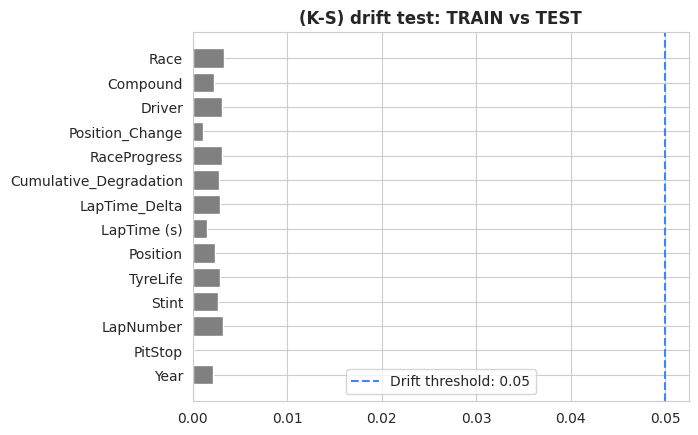

In [33]:
## -- Drift test for TRAIN & TEST --
ks_driftcheck(train, test, 'TEST', BASE)

feature             	ks-stat 	drift
--------------------	------- 	-------
Year                	0.0552  	⚠️ Drift
PitStop             	0.1155  	⚠️ Drift
LapNumber           	0.1871  	⚠️ Drift
Stint               	0.1774  	⚠️ Drift
TyreLife            	0.0155  	✅ Safe!
Position            	0.0177  	✅ Safe!
LapTime (s)         	0.0587  	⚠️ Drift
LapTime_Delta       	0.1789  	⚠️ Drift
Cumulative_Degradation	0.0716  	⚠️ Drift
RaceProgress        	0.1847  	⚠️ Drift
Position_Change     	0.0142  	✅ Safe!
Driver              	0.5206  	⚠️ Drift
Compound            	nan     	✅ Safe!
Race                	0.0154  	✅ Safe!
PitNextLap          	0.0558  	⚠️ Drift



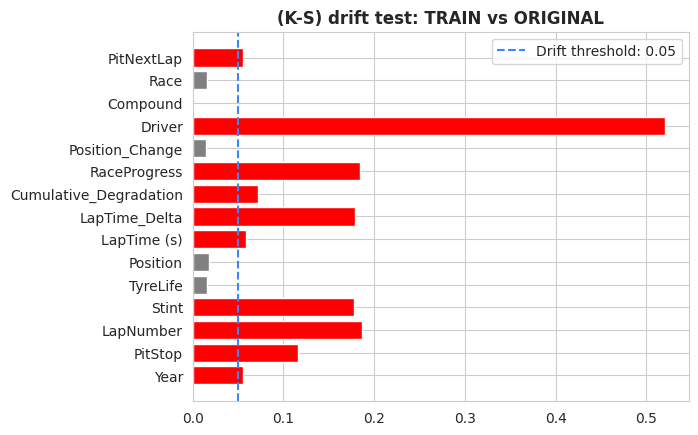

In [34]:
## -- Drift test for TRAIN & ORIGINAL --
ks_driftcheck(train, orig, 'ORIGINAL', BASE+[TARGET])

In [35]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [36]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [37]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories=None):
    if categories != None:
        for c in categories:
            X[c] = X[c].factorize()[0]
            X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
    
    ## -- Compute Model Importances --
    print('Base  model training... ', end='')
    model.fit(X_train, y_train)
    model_importances = pd.Series(model.feature_importances_, index=X.columns)
    print('Complete!')

    ## -- Compute Permutation Importances --
    print('Permutation training... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=5, max_samples=0.95,
        # sample_weight=get_weights(y_test, y),
        scoring='roc_auc',
        random_state=42, n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(15, 8))

    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel('Model importance')

    axs[1].boxplot(
        result.importances[perm_sorted_idx].T,
        tick_labels=X.columns[perm_sorted_idx],
        orientation='horizontal', whis=(0, 100)
    )

    axs[1].axvline(x=0, color='k', linestyle='--')
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle('Impurity-based vs. Permutation on validation data')
    _ = fig.tight_layout()

    df = pd.Series(result.importances_mean[perm_sorted_idx],
                   index=X.columns[perm_sorted_idx]).sort_values(ascending=False)
    print()
    display(df)

print('Plot function script ready!')

Plot function script ready!


Base  model training... Complete!
Permutation training... Complete!



TyreLife                  0.169912
Year                      0.102053
Stint                     0.080056
LapNumber                 0.025699
Race                      0.020834
LapTime_Delta             0.018785
RaceProgress              0.005777
Position_Change           0.003651
Compound                  0.003186
Position                  0.002303
Cumulative_Degradation    0.002183
PitStop                   0.001517
LapTime (s)               0.001295
Driver                   -0.000204
dtype: float64

CPU times: user 17.4 s, sys: 116 ms, total: 17.6 s
Wall time: 29.8 s


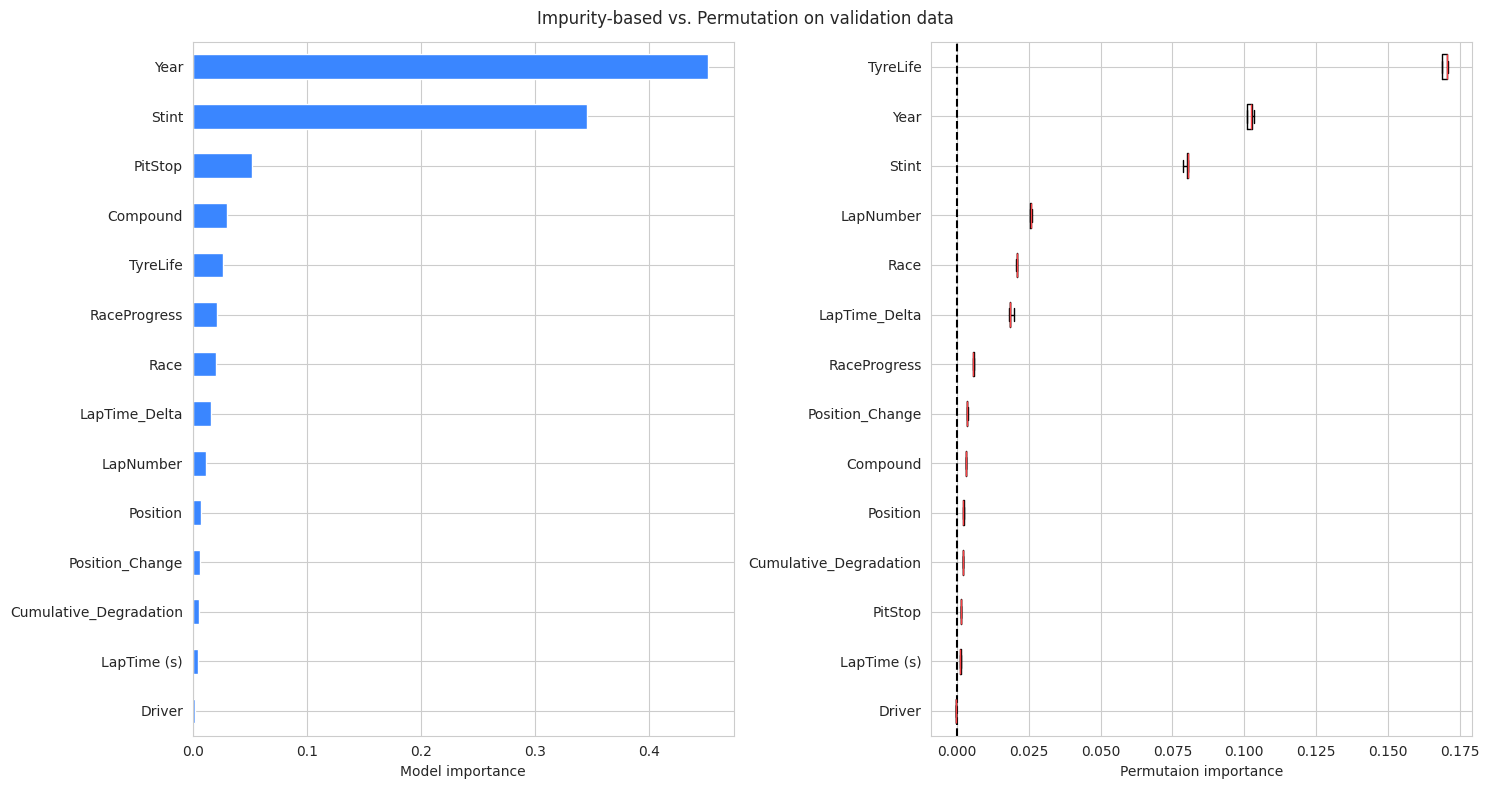

In [38]:
%%time 

PARAMS = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'enable_categorical': True,
    'random_state': CFG.SEED,
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

xgb_model = xgb.XGBClassifier(**PARAMS)

plot_permutation_importance(xgb_model, train[BASE], train[TARGET], CATS_100)

In [39]:
# try:
#     from evidently import Dataset
#     from evidently import DataDefinition
#     from evidently import Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset
# except:
#     !pip install -qq -U evidently
#     from evidently import Dataset
#     from evidently import DataDefinition
#     from evidently import Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset

# def evid_driftcheck(df_1, df_2, features, nums, cats):

#     schema = DataDefinition(numerical_columns=nums, categorical_columns=cats)

#     train_df = Dataset.from_pandas(df_1[features], data_definition=schema)
#     test_df = Dataset.from_pandas(df_2[features], data_definition=schema)

#     report = Report([DataDriftPreset()])
#     my_eval = report.run(train_df, test_df)

#     display(my_eval)

In [40]:
## -- Drift test for TRAIN & TEST --
# evid_driftcheck(train, test, BASE, NUMS, CATS)

In [41]:
## -- Drift test for TRAIN & ORIGINAL --
# evid_driftcheck(train, orig, train.columns, NUMS, CATS)

In [42]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [43]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [44]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:1000],
#     features=BASE,
#     target=TARGET,
#     ## --- (count, mean, count, std, nunique, median, max, min)
#     aggs=['mean'],
#     fill_nan=True,
# )

# print(ORIG_COLS)

In [45]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('✓ Total Features:', len(FEATURES))

X = train[FEATURES]
y = train[TARGET]

# group = train['Stint'].to_numpy()
# kfold = GroupKFold(n_splits=len(np.unique(group)), shuffle=True, random_state=CFG.SEED)

N_SPLITS = 5
kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CFG.SEED)

X.head(3)

✓ Total Features: 14


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,0,0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0
1,1,0,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0
2,2,0,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0


# ML TRAINING

## ~ TREE MODELS

In [46]:
## -- Define Models --
tree_models = {
    'xgb_': xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=CFG.SEED,
        enable_categorical=True,
        n_jobs=os.cpu_count(),
        verbosity=0,
        device='cuda' if torch.cuda.is_available() else 'cpu',
    ),
    'lgb_': lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        verbose=-1,
        random_state=CFG.SEED,
        nthreads=os.cpu_count(),
        device='gpu' if torch.cuda.is_available() else 'cpu',
    ),
    'cat_': cgb.CatBoostClassifier(
        loss_function='Logloss', # -> also 'CrossEntropy'
        eval_metric='AUC',
        cat_features=CATS_100,
        verbose=0,
        random_state=CFG.SEED,
        allow_writing_files=False,
        thread_count=os.cpu_count(),
        task_type='GPU' if torch.cuda.is_available() else 'CPU',
    ),
    'rfc_': RandomForestClassifier(
        # n_estimators=20,
        # max_depth=5,
        n_jobs=os.cpu_count(),
        random_state=CFG.SEED,
    ),
    'hist_': HistGradientBoostingClassifier(tol=1e-4, random_state=CFG.SEED),
}

print(f"Tree Models to train: {len(tree_models)} -> ", end='')
print(list(tree_models.keys()))

Tree Models to train: 5 -> ['xgb_', 'lgb_', 'cat_', 'rfc_', 'hist_']


Training Models:   0%|          | 0/5 [00:00<?, ?it/s]


[1]XGB_ █████████████████████████
### FOLD 1/5 | (351312, 14) | Score: 0.94391 ###
### FOLD 2/5 | (351312, 14) | Score: 0.94222 ###
### FOLD 3/5 | (351312, 14) | Score: 0.94322 ###
### FOLD 4/5 | (351312, 14) | Score: 0.94271 ###
### FOLD 5/5 | (351312, 14) | Score: 0.94371 ###
OOF Score: 0.94315
AVG Score: 0.94315 ± 0.00063
Time: 26.39 secs


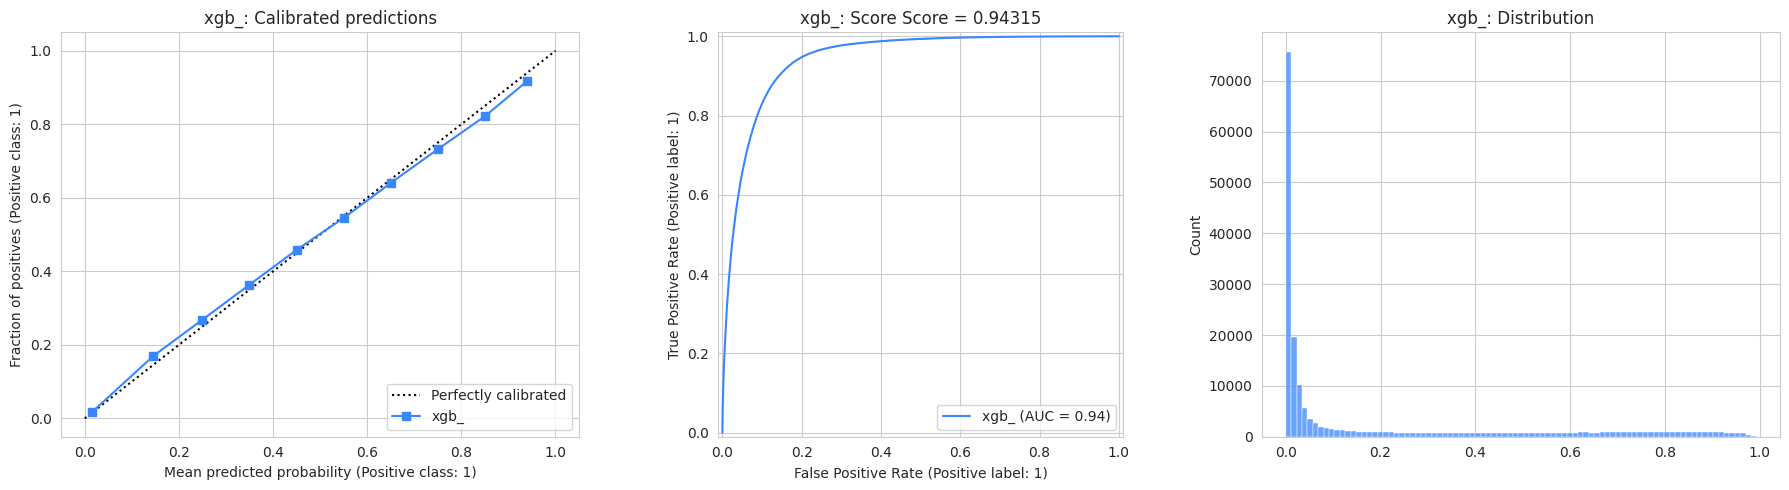


[2]LGB_ █████████████████████████
### FOLD 1/5 | (351312, 14) | Score: 0.94400 ###
### FOLD 2/5 | (351312, 14) | Score: 0.94194 ###
### FOLD 3/5 | (351312, 14) | Score: 0.94329 ###
### FOLD 4/5 | (351312, 14) | Score: 0.94224 ###
### FOLD 5/5 | (351312, 14) | Score: 0.94313 ###
OOF Score: 0.94291
AVG Score: 0.94292 ± 0.00074
Time: 22.21 secs


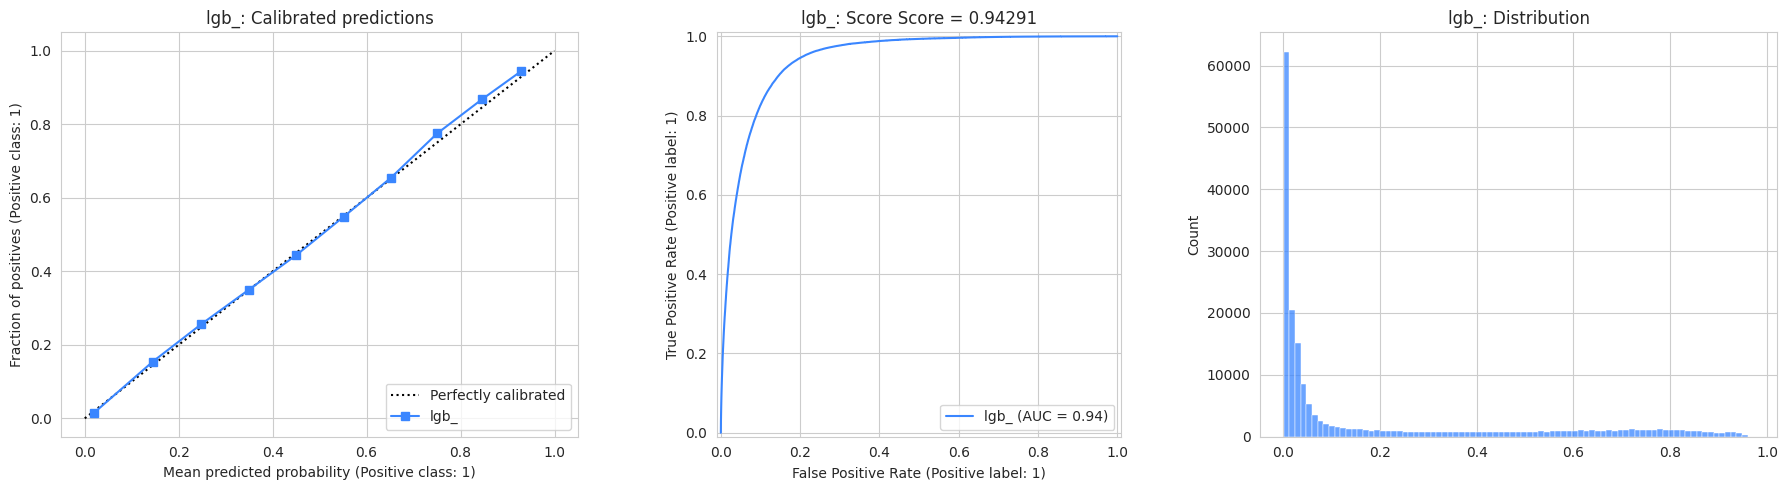


[3]CAT_ █████████████████████████
### FOLD 1/5 | (351312, 14) | Score: 0.94933 ###
### FOLD 2/5 | (351312, 14) | Score: 0.94712 ###
### FOLD 3/5 | (351312, 14) | Score: 0.94835 ###
### FOLD 4/5 | (351312, 14) | Score: 0.94775 ###
### FOLD 5/5 | (351312, 14) | Score: 0.94872 ###
OOF Score: 0.94825
AVG Score: 0.94825 ± 0.00077
Time: 1541.30 secs


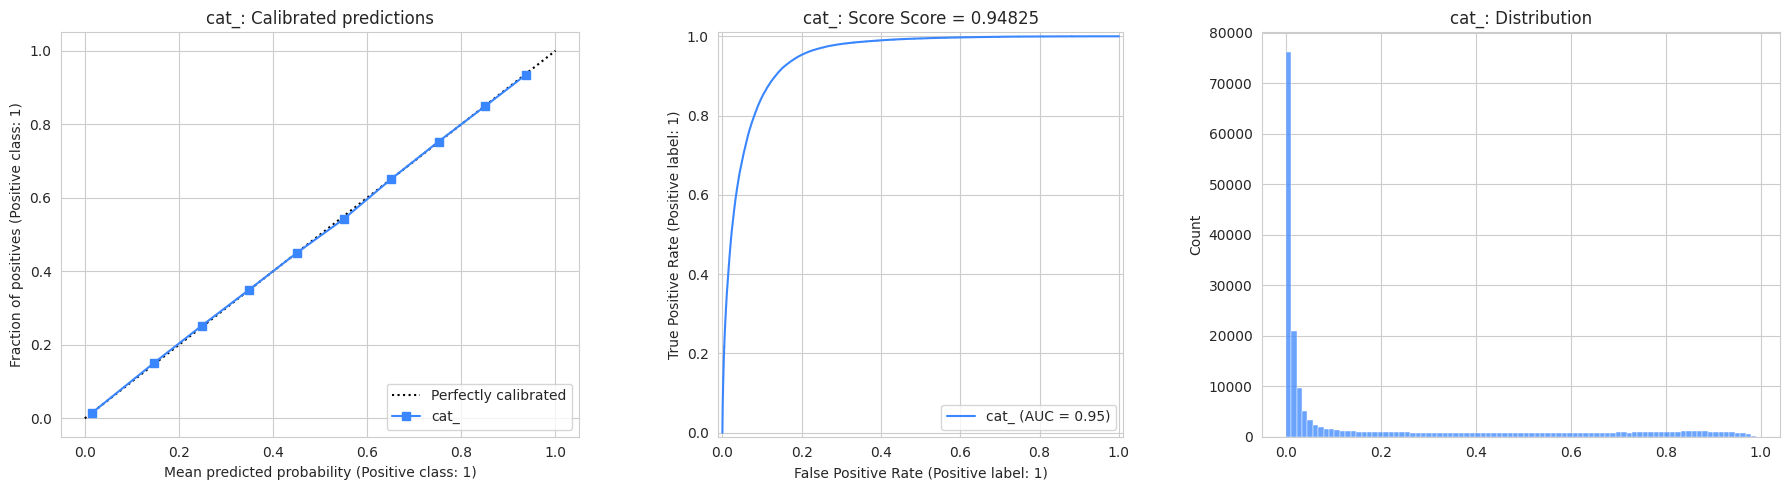


[4]RFC_ █████████████████████████
### FOLD 1/5 | (351312, 14) | Score: 0.93592 ###
### FOLD 2/5 | (351312, 14) | Score: 0.93403 ###
### FOLD 3/5 | (351312, 14) | Score: 0.93572 ###
### FOLD 4/5 | (351312, 14) | Score: 0.93263 ###
### FOLD 5/5 | (351312, 14) | Score: 0.93551 ###
OOF Score: 0.93477
AVG Score: 0.93476 ± 0.00126
Time: 233.31 secs


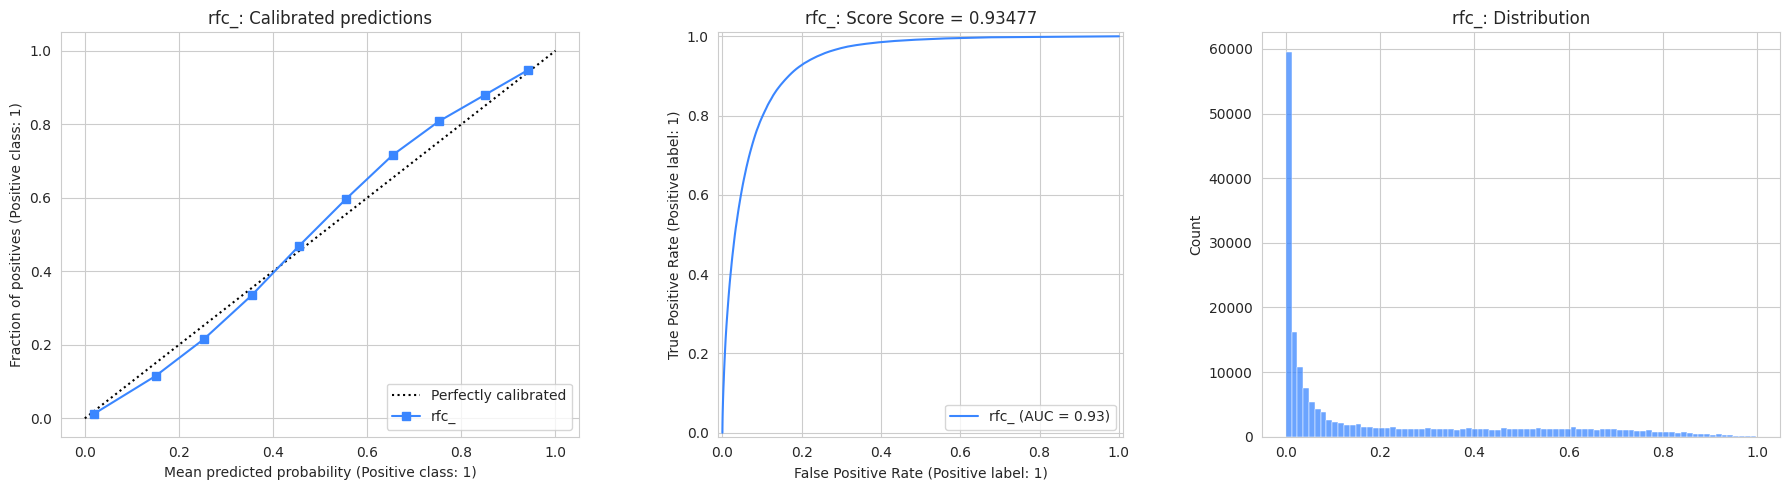


[5]HIST_ █████████████████████████
### FOLD 1/5 | (351312, 14) | Score: 0.94357 ###
### FOLD 2/5 | (351312, 14) | Score: 0.94164 ###
### FOLD 3/5 | (351312, 14) | Score: 0.94314 ###
### FOLD 4/5 | (351312, 14) | Score: 0.94168 ###
### FOLD 5/5 | (351312, 14) | Score: 0.94261 ###
OOF Score: 0.94252
AVG Score: 0.94253 ± 0.00077
Time: 35.37 secs


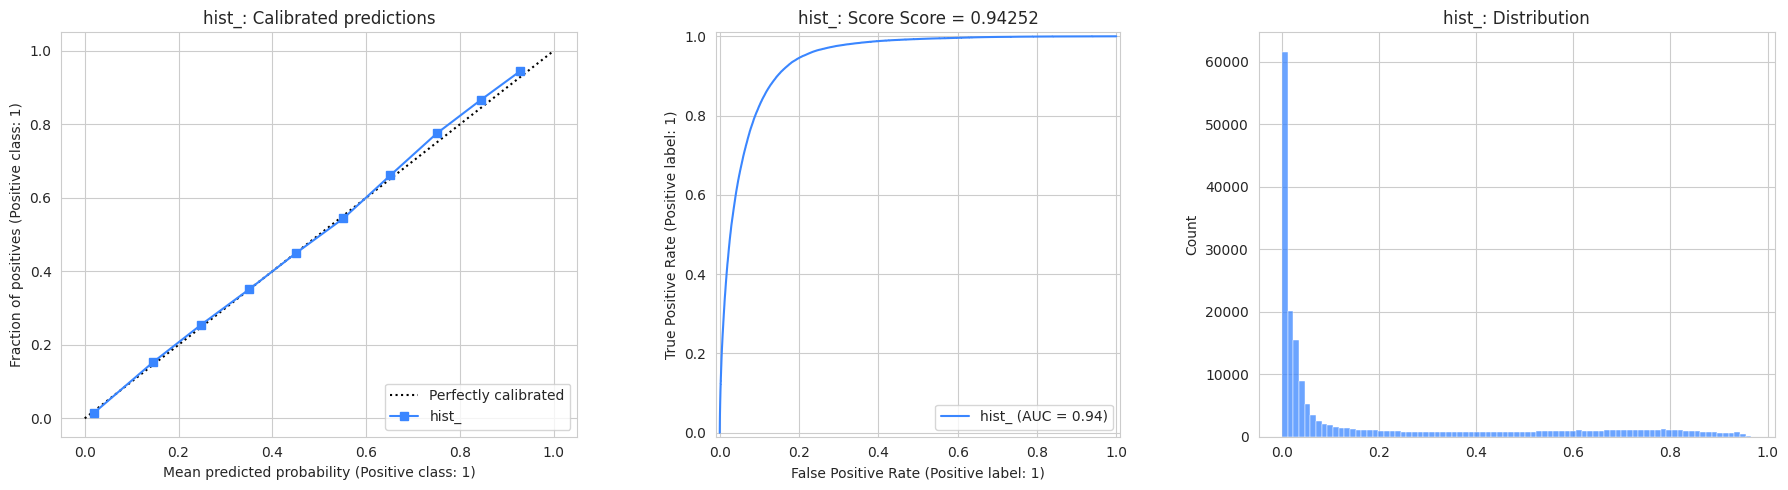

In [47]:
## -- Initiate GBDTs Training --
TREE_MODELS = {}

oof_final    = pd.DataFrame()
test_final   = pd.DataFrame()
model_scores = pd.Series()

desc = 'Training Models'
for i, (name, model) in tqdm(enumerate(tree_models.items()), total=len(tree_models), desc=desc):
    print(f"\n{CFG.YELLOW}[{i+1}]{(name.upper())} {'█'*25}{CFG.RESET}")
    tik = time()

    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(test))
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test[FEATURES].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=FEATURES,
        #     target=TARGET,
        #     aggs=['mean'], # (mean, count, std, nunique, median, max, min)
        #     # fill_nan=True,
        # )

        ## -- TE Opt1. -> Using CUSTOM --
        # te_cols = [c for c in FEATURES if X_train[c].nunique()<=1000]
        # TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        # X_train = TE.fit_transform(X_train, y_train)
        # X_val   = TE.transform(X_val)
        # X_test  = TE.transform(X_test)

        combine = pd.concat([X_train, X_val, X_test])
        for c in CATS_100:
            combine[c] = combine[c].factorize()[0]
            combine[c] = combine[c].astype('category')
        X_train = combine.iloc[:len(X_train)]
        X_val   = combine.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combine.iloc[len(X_train)+len(X_val):]

        print(f"### FOLD {fold+1}/{kfold.n_splits} | ", end='')
        print(f"{X_train.shape} | ", end='')

        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1]

        fold_score = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"Score: {fold_score:.5f} ###")


    test_preds /= kfold.n_splits

    ## -- After all folds --
    overall_score = np.round(roc_auc_score(y, oof_preds), 5)
    print(f"{'='*27}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"{'='*27}")

    tok = time()
    tiktok = tok-tik
    print(f"Time: {tiktok:.2f} secs")

    _, axs = plt.subplots(1, 3, figsize=(18, 5)) #, width_ratios=[0.6,0.4]

    CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
    axs[0].set_title(f"{name}: Calibrated predictions")

    RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
    axs[1].set_title(f"{name}: Score Score = {overall_score}")
    ## -- axs[1].grid(False)

    sns.histplot(test_preds, ax=axs[2])
    axs[2].set_title(f"{name}: Distribution")

    plt.tight_layout()
    plt.show()

    n = name + str(overall_score).split('.')[1]
    oof_final[n]    = oof_preds
    test_final[n]   = test_preds
    TREE_MODELS[n]  = model
    model_scores[n] = overall_score

    gc.collect()

In [48]:
# 5 FOLDS
# xgb = 0.94315 ± 0.00063
# lgb = 0.94292 ± 0.00074
# rfc = 0.93476 ± 0.00126

# 10 FOLDS
# xgb = 0.94375 ± 0.00096
# lgb = 0.94311 ± 0.00097
# rfc = 0.93492 ± 0.00134

In [49]:
model_scores

xgb_94315     0.94315
lgb_94291     0.94291
cat_94825     0.94825
rfc_93477     0.93477
hist_94252    0.94252
dtype: float64

In [50]:
X_train.head(3)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,0,0,0,0,0,0,0,0,0,78.491,-7.564,21.019,0.714286,0
1,1,0,1,1,1,1,0,1,1,75.095,-32.617,-223.207,0.346154,1
2,2,0,2,0,0,2,1,2,2,70.945,-7.540,-100.529,0.819444,2


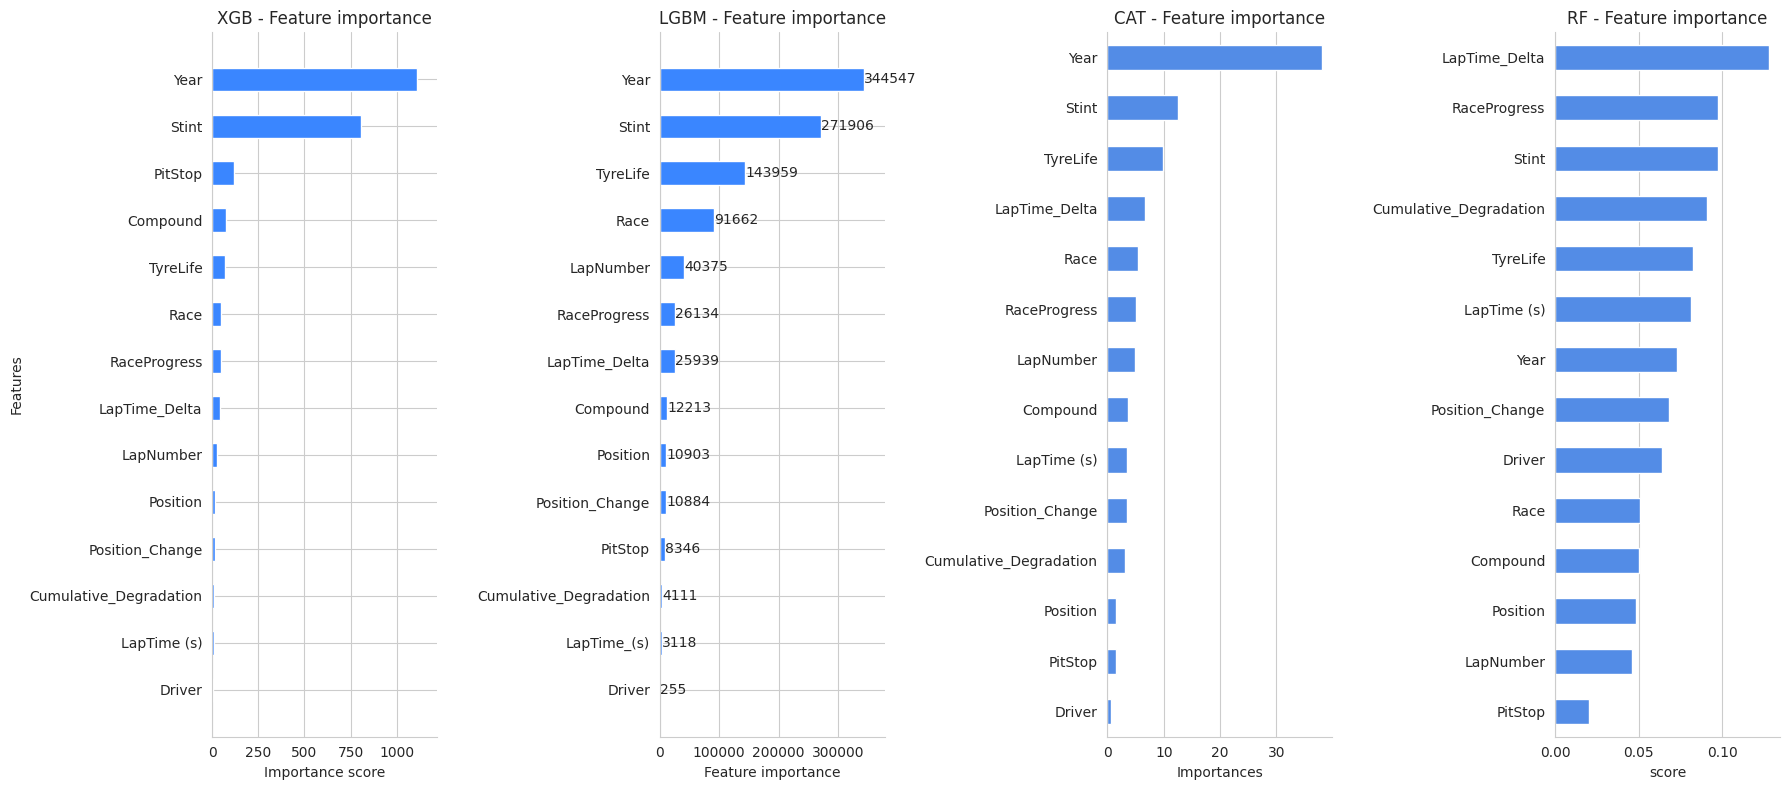

In [51]:
## -- Plot Feature Importances --
MAX = 15
fig, axs = plt.subplots(1, 4, figsize=(18, 8))

## -- XGBoost --
for k, v in TREE_MODELS.items():
    if 'xgb' in k:
        xgb.plot_importance(
            v, max_num_features=MAX,
            importance_type='gain',
            title='XGB - Feature importance',
            height=0.5, show_values=False, ax=axs[0], # grid=False,
        )

    ## -- LightGBM --
    elif 'lgb' in k:
        lgb.plot_importance(
            v, max_num_features=MAX,
            importance_type='gain',
            title='LGBM - Feature importance',
            height=0.5, precision=0, ax=axs[1], # grid=False,
        )
        axs[1].set_ylabel('')

    ## -- CatBoost --
    elif 'cat' in k:
        cat_imp_df = v.get_feature_importance(prettified=True).iloc[:MAX]
        sns.barplot(data=cat_imp_df, x='Importances', y='Feature Id', width=0.5, ax=axs[2])
        axs[2].set_title('CAT - Feature importance')
        axs[2].set_ylabel('')

    ## -- RandomForest --
    elif 'rfc' in k:
        rf_dicts = dict(zip(X_train.columns, v.feature_importances_))
        rf_imp_df = pd.DataFrame.from_dict(rf_dicts, orient='index', columns=['score'])\
                                .sort_values('score', ascending=False).iloc[:MAX]
        sns.barplot(rf_imp_df, x=rf_imp_df.score, y=rf_imp_df.index, width=0.5, ax=axs[3])
        axs[3].set_title('RF - Feature importance')
        axs[3].set_ylabel('')

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [52]:
try:
    import shap
except:
    %pip install -q -U shap
    import shap

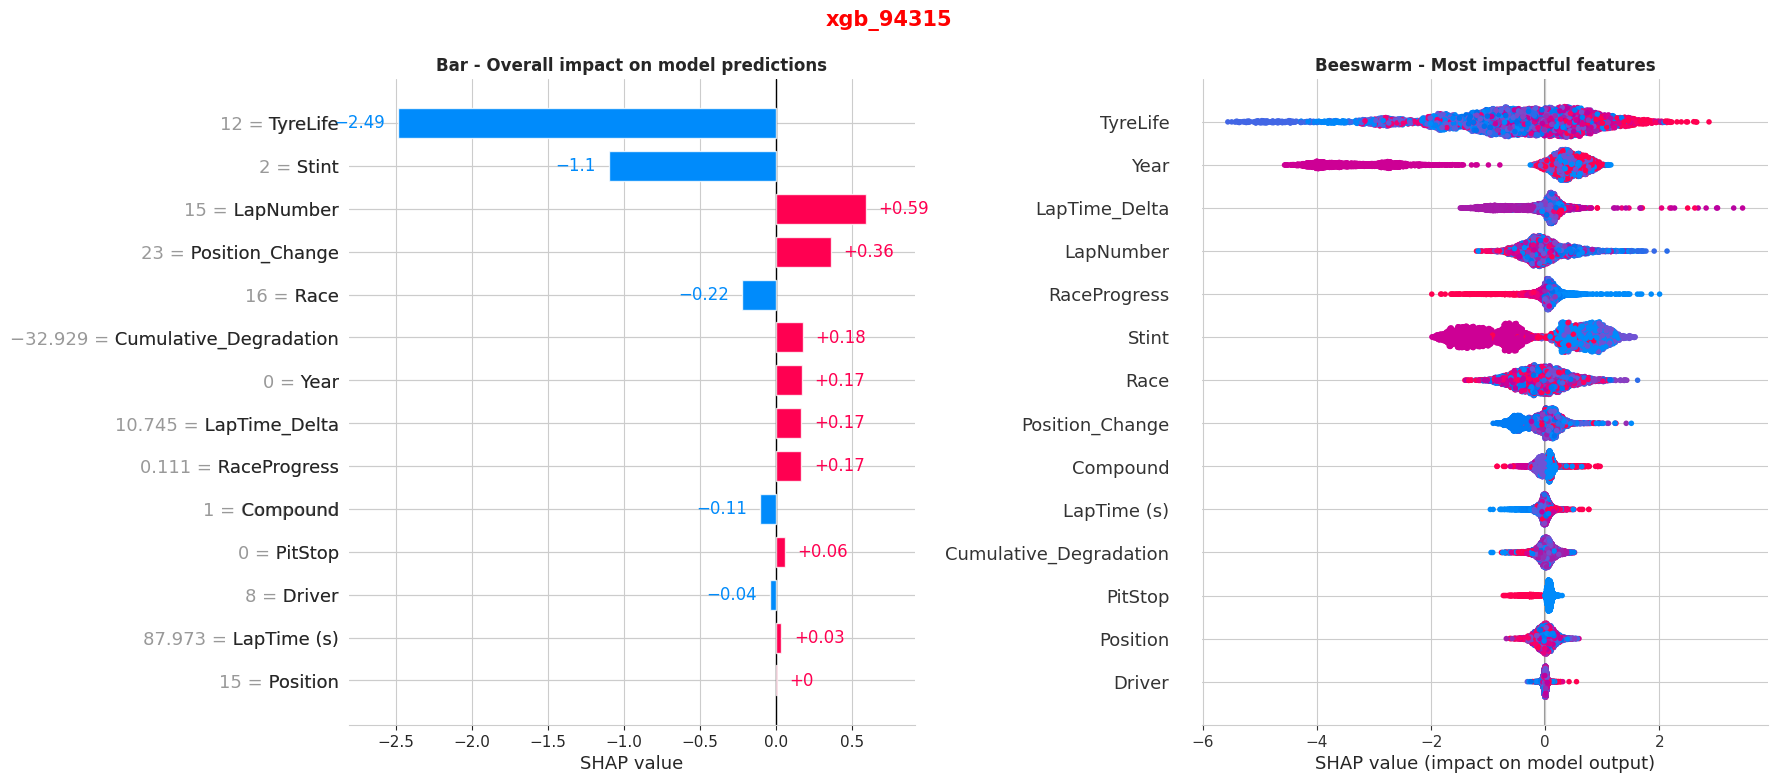

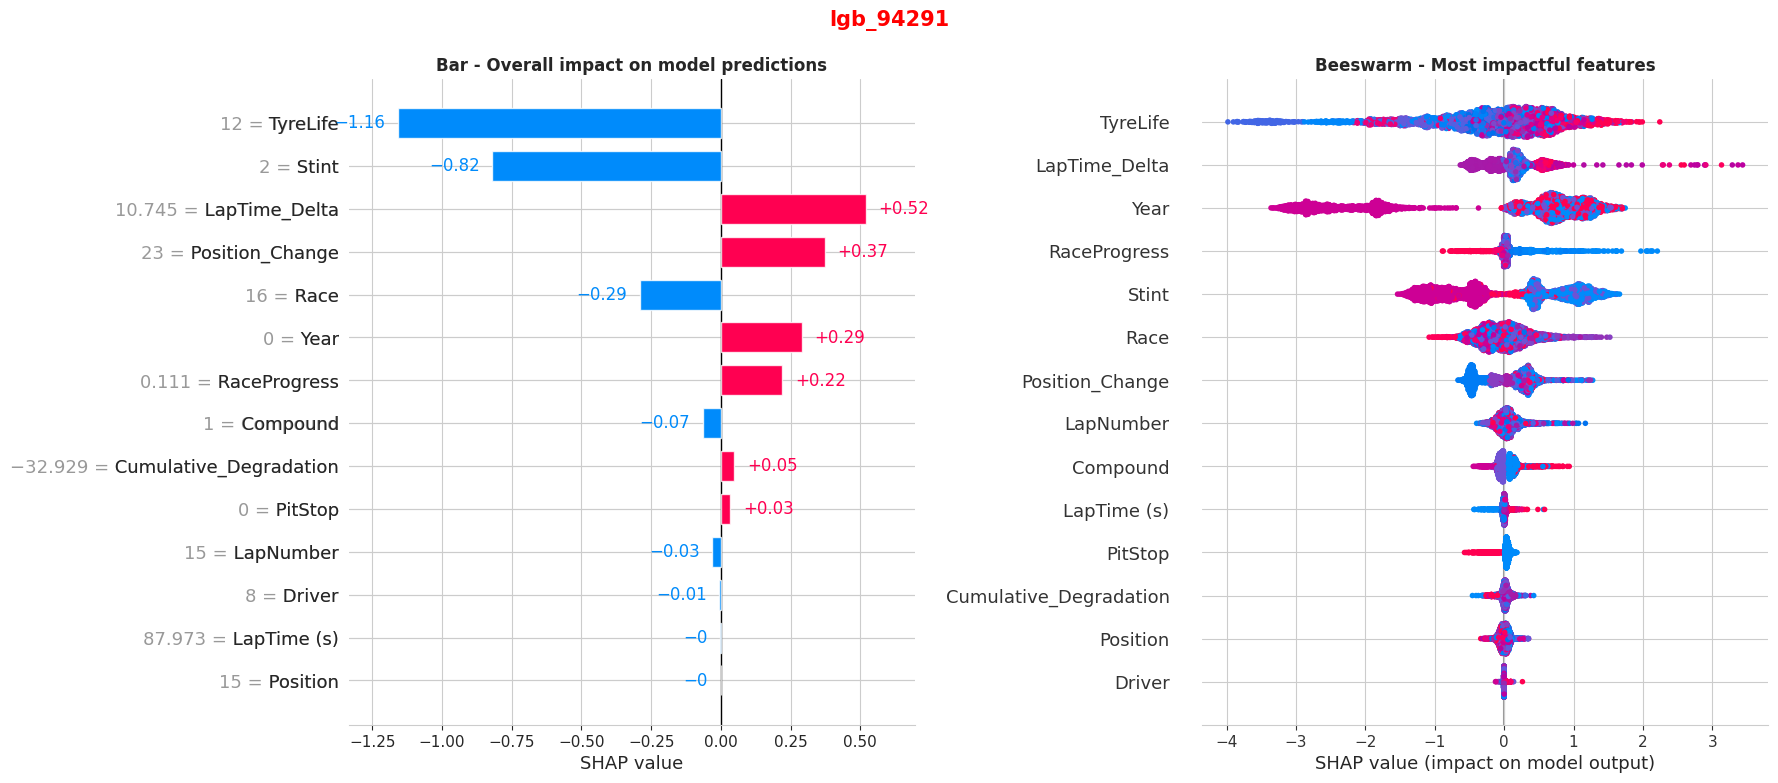

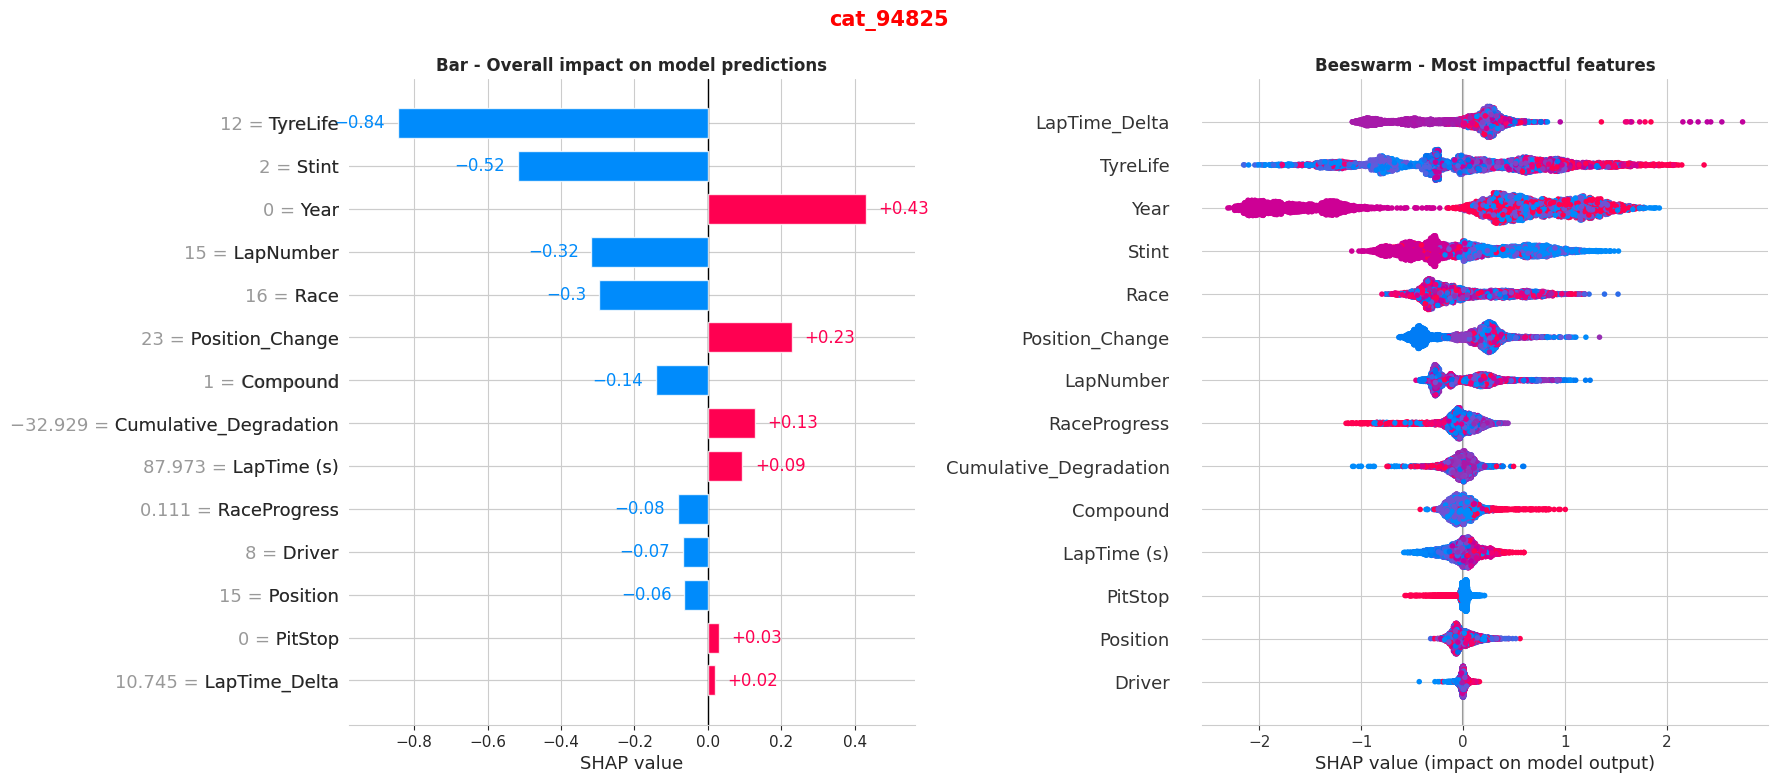

In [53]:
## -- Plot SHAP values --
MAX = 15

for i, (name, model) in enumerate(TREE_MODELS.items()):
    if 'xgb' in name or 'lgb' in name or 'cat' in name:
        explainer = shap.TreeExplainer(model)
        explanation = explainer(X_val.iloc[:5000])

        ## -- Bar plot --
        plt.subplot(121)
        shap.plots.bar(explanation[0], max_display=MAX, show=False)
        plt.title('Bar - Overall impact on model predictions', fontweight='semibold')

        ## -- Beeswarm plot --
        plt.subplot(122)
        shap.plots.beeswarm(
            explanation, max_display=MAX, order=explanation.abs.max(0),
            plot_size=(18, 8), color_bar=False, show=False,
        )

        plt.title('Beeswarm - Most impactful features', fontweight='semibold')
        plt.suptitle(f"{name}", fontweight='bold', fontsize=15, color='r')

        plt.tight_layout(pad=1.5)
        plt.show()
        print()

In [54]:
display(oof_final.head(3))
print()
display(test_final.head(3))

,xgb_94315,lgb_94291,cat_94825,rfc_93477,hist_94252
0,0.746657,0.748463,0.834372,0.76,0.767608
1,0.631101,0.354439,0.808303,0.62,0.354168
2,0.294776,0.459581,0.473768,0.56,0.513137


,xgb_94315,lgb_94291,cat_94825,rfc_93477,hist_94252
0,0.006809,0.005044,0.005361,0.006,0.005338
1,0.001741,0.003141,0.002533,0.002,0.003133
2,0.002608,0.005067,0.005205,0.000,0.004781


## ~ LINEAR MODELS

### ~ LINEAR MODELS 1: OHE ONLY CATS

In [55]:
## -- Define Models --
linear_models = {
    'log_': LogisticRegressionCV(
        max_iter=10_000,
        tol=1e-4,
        cv=5,
        scoring='neg_log_loss',
        # class_weight='balanced',
        n_jobs=os.cpu_count(),
        random_state=CFG.SEED,
    ),
    'mlp_': MLPClassifier(
        max_iter=100,
        tol=1e-4,
        random_state=CFG.SEED,
    ),
}

print(f"Linear Models to train: {len(linear_models)} -> ", end="")
print(list(linear_models.keys()))

Linear Models to train: 2 -> ['log_', 'mlp_']


Training Models:   0%|          | 0/2 [00:00<?, ?it/s]


[1] log_ ████████████████████
	FOLD 1/5 Score: 0.92051
	FOLD 2/5 Score: 0.91702
	FOLD 3/5 Score: 0.91902
	FOLD 4/5 Score: 0.91755
	FOLD 5/5 Score: 0.91955
-------------------------------
OOF Score: 0.91873
AVG Score: 0.91873 ± 0.00129
-------------------------------
Best 'C': [0.04641589]
Time: 52.53 secs


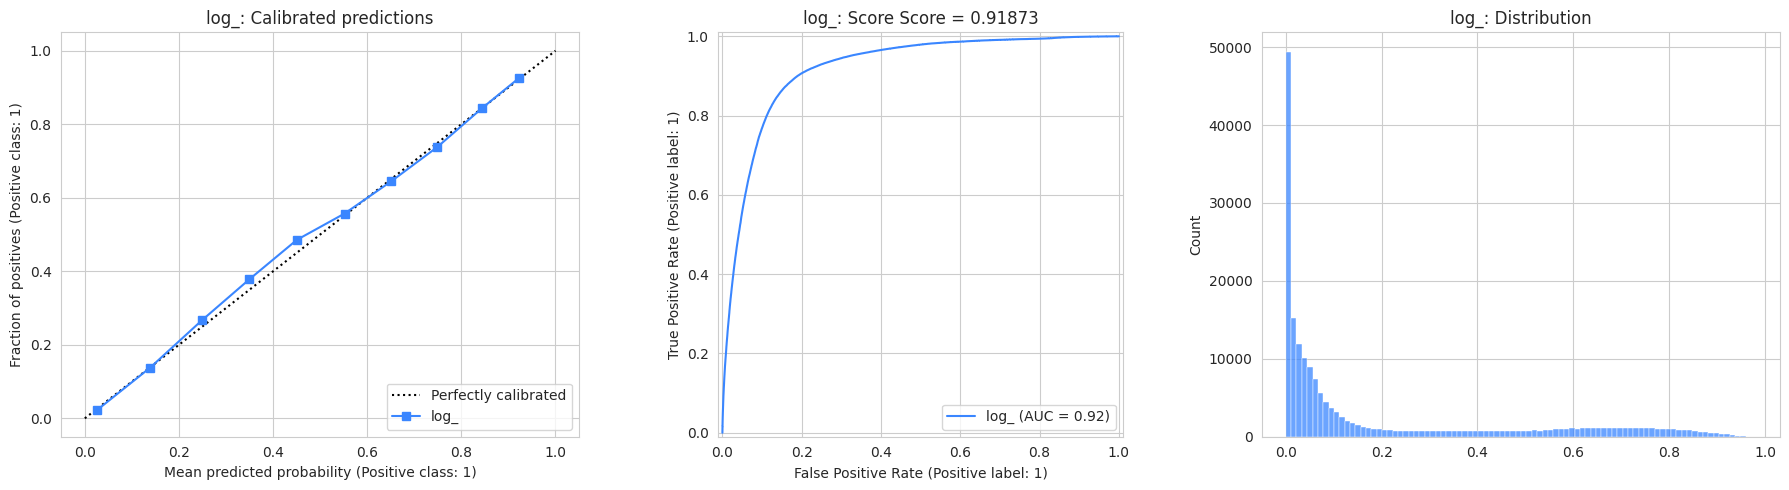


[2] mlp_ ████████████████████
	FOLD 1/5 Score: 0.92702
	FOLD 2/5 Score: 0.92424
	FOLD 3/5 Score: 0.92689
	FOLD 4/5 Score: 0.92656
	FOLD 5/5 Score: 0.92580
-------------------------------
OOF Score: 0.92592
AVG Score: 0.92610 ± 0.00102
-------------------------------
Time: 1767.62 secs


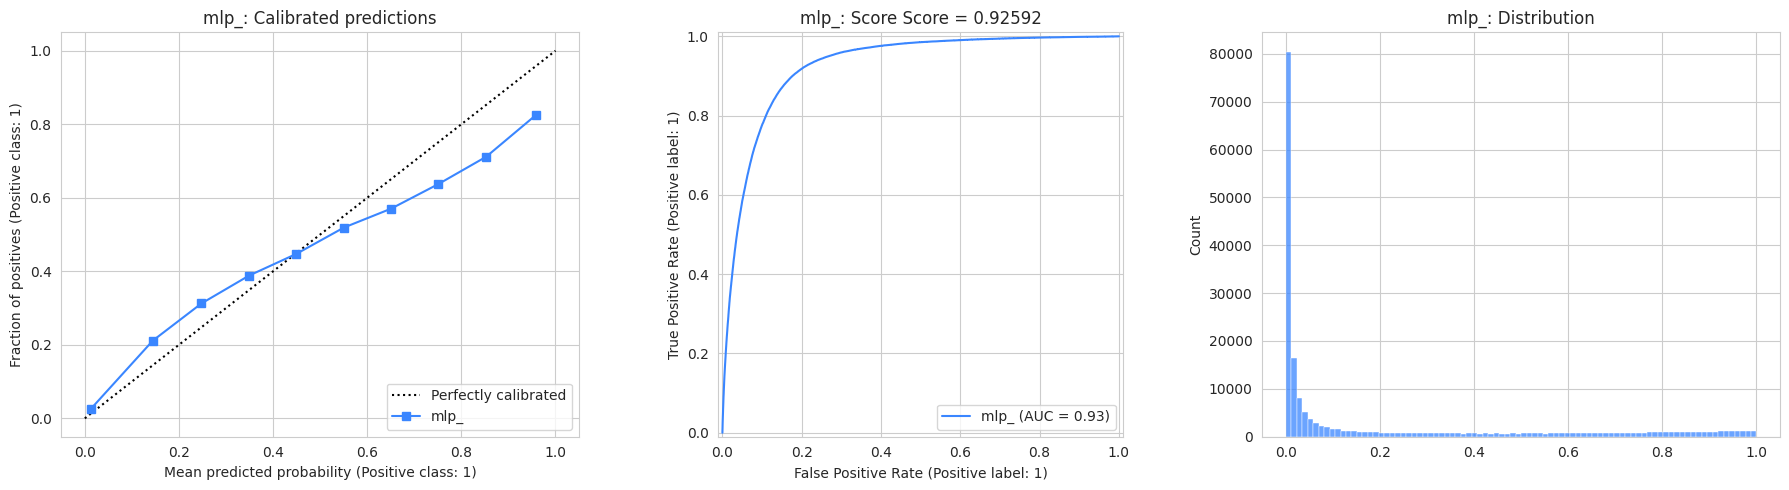

In [56]:
## -- Initiate LINEAR Training 1 --
LINEAR_MODELS_1 = {}

for i, (name, model) in tqdm(enumerate(linear_models.items()), total=len(linear_models), desc=desc):

    print(f"\n[{i+1}] {name} {'█'*20}")

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test))
    fold_scores = []

    tik = time()

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test[FEATURES].copy()

        # for c in CATS:
        #     combine[c] = combine[c].factorize()[0]

        # X_train = combine.iloc[:len(X_train)]
        # X_val   = combine.iloc[len(X_train):len(X_train)+len(X_val)]
        # X_test  = combine.iloc[len(X_train)+len(X_val):]

        ## -- Create pipeline --
        lr_model = make_pipeline(
            make_column_transformer(
                (OneHotEncoder(
                    handle_unknown='ignore',
                    # sparse_output=False,
                    drop=None,
                ), CATS_100), # list(set(CATS_100+CATS))
                remainder='passthrough',
                n_jobs=os.cpu_count(),
            ),
            StandardScaler(with_mean=False),
            model,
        )

        lr_model.fit(X_train, y_train)

        oof_preds[val_idx] = lr_model.predict_proba(X_val)[:, 1]
        test_preds += lr_model.predict_proba(X_test)[:, 1]

        fold_score = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"\tFOLD {fold+1}/{kfold.n_splits} Score: {fold_score:.5f}")

    tok = time()
    tiktok = tok-tik

    test_preds /= kfold.n_splits

    ## -- After all folds --
    overall_score = np.round(roc_auc_score(y, oof_preds), 5)

    print(f"{'-'*31}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"{'-'*31}")
    if 'log' in name:
        print(f"Best 'C': {lr_model[-1].C_}")
    print(f"Time: {tiktok:.2f} secs")

    _, axs = plt.subplots(1, 3, figsize=(18, 5)) #, width_ratios=[0.6,0.4]
    # Right: Confusion matrix (threshold = 0.5)
    pred_labels = (oof_preds >= 0.5).astype('int8')

    CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
    axs[0].set_title(f"{name}: Calibrated predictions")

    # Left: ROC curve
    RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
    axs[1].set_title(f"{name}: Score Score = {overall_score}")
    # axs[1].grid(False)

    sns.histplot(test_preds, ax=axs[2])
    axs[2].set_title(f"{name}: Distribution")

    plt.tight_layout()
    plt.show()

    n = name + str(overall_score).split('.')[1]
    oof_final[n]       = oof_preds
    test_final[n]      = test_preds
    LINEAR_MODELS_1[n] = lr_model
    model_scores[n]    = overall_score

    gc.collect()

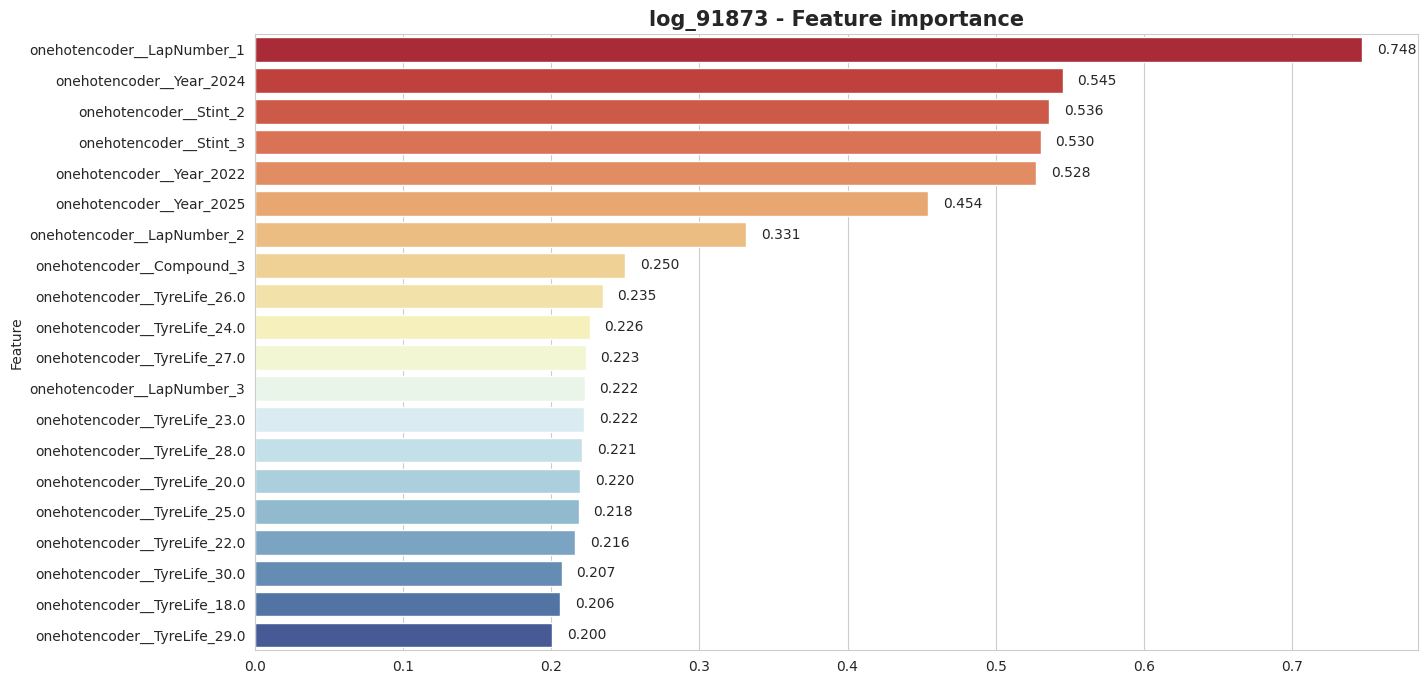

In [57]:
## -- Feature Importances: Linear Model --
for i, name in enumerate(list(LINEAR_MODELS_1.keys())):
    if 'log' in name:
        coef_dict = dict(zip(
            LINEAR_MODELS_1[name][0].get_feature_names_out(),
            LINEAR_MODELS_1[name][-1].coef_[0]
        ))

        reg_imp = pd.Series(coef_dict).sort_values(ascending=False).iloc[:20] # Top n features

        plt.figure(figsize=(15, 8))
        sns.barplot(reg_imp, orient='h', palette='RdYlBu')
        plt.ylabel('Feature')
        plt.title(f'{name} - Feature importance', fontdict={'size': 15, 'weight': 'bold'})

        for i, t in enumerate(reg_imp.values):
            plt.text(t+1e-2, i, f'{t:.3f}', va='center', )

        plt.show()

### ~ LINEAR MODELS 2: OHE ALL FEATURES

In [58]:
# ## -- Define Models --
# linear_models2 = {
#     'log2v_': LogisticRegressionCV(
#         max_iter=10_000,
#         tol=1e-4,
#         cv=5,
#         scoring='neg_log_loss',
#         # class_weight='balanced',
#         n_jobs=os.cpu_count(),
#         random_state=CFG.SEED,
#     ),
#     'mlp2v_': MLPClassifier(
#         max_iter=100,
#         tol=1e-4,
#         random_state=CFG.SEED,
#     ),
# }

# print(f"Linear Models to train: {len(linear_models2)} -> ", end="")
# print(list(linear_models2.keys()))

In [59]:
# ## -- Initiate LINEAR Training 2 --
# LINEAR_MODELS_2 = {}

# for i, (name, model) in tqdm(enumerate(linear_models2.items()), total=len(linear_models2), desc=desc):
#     print(f"\n[{i+1}] {name} {'█'*25}")
#     tik = time()

#     oof_preds  = np.zeros(len(X))
#     test_preds = np.zeros(len(test))
#     fold_scores  = []

#     for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
#         X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test[FEATURES].copy()

#         combine = pd.concat([X_train, X_val, X_test])
#         for c in [c for c in X_train.columns if X_train[c].dtype != np.number]:
#             combine[c] = combine[c].factorize()[0]

#         for c in CATS:
#             combine[c] = combine[c].factorize()[0]

#         X_train = combine.iloc[:len(X_train)]
#         X_val   = combine.iloc[len(X_train):len(X_train)+len(X_val)]
#         X_test  = combine.iloc[len(X_train)+len(X_val):]

#         ## -- Create pipeline --
#         lr_model_2 = make_pipeline(
#             make_column_transformer(
#                 (OneHotEncoder(
#                     handle_unknown='ignore',
#                     # sparse_output=False,
#                     drop=None,
#                 ), CATS_100),
#                 remainder='passthrough',
#                 n_jobs=os.cpu_count(),
#             ),
#             StandardScaler(with_mean=False),
#             model,
#         )

#         lr_model_2.fit(X_train, y_train)

#         oof_preds[val_idx] = lr_model_2.predict_proba(X_val)[:, 1]
#         test_preds += lr_model_2.predict_proba(X_test)[:, 1]

#         fold_score = roc_auc_score(y_val, oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"Fold {fold+1}/{kfold.n_splits} Score: {fold_score:.5f}")


#     test_preds /= kfold.n_splits

#     tok = time()
#     tiktok = tok-tik

#     ## -- After all folds --
#     overall_score = np.round(roc_auc_score(y, oof_preds), 5)

#     print(f"{'-'*30}")
#     print(f"OOF Score: {overall_score}")
#     print(f"AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print(f"{'-'*30}")
#     print(f"Best 'C' value: {lr_model_2[-1].C_}")
#     print(f"Time: {tiktok:.2f} secs")

#     _, axs = plt.subplots(1, 3, figsize=(18, 5))

#     CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
#     axs[0].set_title(f"{name}: Calibrated predictions")

#     # Left: ROC-Score curve
#     RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
#     axs[1].set_title(f"{name} Score: {overall_score}")
#     # axs[1].grid(False)

#     sns.histplot(test_preds, ax=axs[2])
#     axs[2].set_title(f"{name} Distribution")

#     plt.tight_layout()
#     plt.show()

#     n = name + str(overall_score).split('.')[1]
#     oof_final[n]       = oof_preds
#     test_final[n]      = test_preds
#     LINEAR_MODELS_2[n] = lr_model_2
#     model_scores[n]    = overall_score

#     gc.collect()

In [60]:
# ## -- Feature Importances: Linear Model --
# for i, name in enumerate(list(LINEAR_MODELS_2.keys())):
#     if 'log' in name:
#         coef_dict = dict(
#             zip(
#                 LINEAR_MODELS_2[name][0].get_feature_names_out(),
#                 LINEAR_MODELS_2[name][-1].coef_[0]
#             )
#         )

#         reg_imp = pd.Series(coef_dict).sort_values(ascending=False).iloc[:20] # Top n features

#         plt.figure(figsize=(15, 8))
#         sns.barplot(reg_imp, orient='h', palette='RdYlBu')
#         plt.ylabel('Feature')
#         plt.title(f'{name} - Feature importance', fontdict={'size': 15, 'weight': 'bold'})

#         for i, t in enumerate(reg_imp.values):
#             plt.text(t+1e-2, i, f'{t:.3f}', va='center', )

#         plt.show()

In [61]:
# ## -- Define Models --
# linear_models3 = {
#     'log3_': LogisticRegressionCV(
#         max_iter=1000,
#         tol=1e-4,
#         cv=5,
#         scoring='neg_log_loss',
#         # class_weight='balanced',
#         n_jobs=os.cpu_count(),
#         random_state=CFG.SEED,
#     ),
# }

# print(f"Linear Models to train: {len(linear_models3)} -> ", end="")
# print(list(linear_models3.keys()))

In [62]:
# ## -- Initiate LINEAR Training 2 --
# LINEAR_MODELS_3 = {}

# for i, (name, model) in tqdm(
#     enumerate(linear_models3.items()),
#     total=len(linear_models3),
#     desc='Training Models.'
# ):
#     print(f"\n[{i+1}] {name} {'█'*25}")
#     tik = time()

#     oof_preds  = np.zeros(len(X))
#     test_preds = np.zeros(len(test))
#     fold_scores = []

#     for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
#         X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test[FEATURES].copy()

#         ## -- Create pipeline --
#         lr_model_3 = make_pipeline(
#             make_column_transformer(
#                 (OneHotEncoder(
#                     handle_unknown='ignore',
#                     # sparse_output=False,
#                     # drop='first',
#                 ), FEATURES),
#                 remainder='passthrough',
#                 n_jobs=os.cpu_count(),
#             ),
#             StandardScaler(with_mean=False),
#             model,
#         )

#         lr_model_3.fit(X_train, y_train)

#         oof_preds[val_idx] = lr_model_3.predict_proba(X_val)[:,1]
#         fold_score = roc_auc_score(y_val, oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"Fold {fold+1}/{kfold.n_splits} Score: {fold_score:.5f}")

#         test_preds += lr_model_3.predict_proba(X_test)[:,1]

#     test_preds /= kfold.n_splits

#     tok = time()
#     tiktok = tok-tik

#     ## -- After all folds --
#     overall_score = np.round(roc_auc_score(y, oof_preds), 5)

#     print(f"{'-'*30}")
#     print(f"OOF Score: {overall_score}")
#     print(f"AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print(f"{'-'*30}")
#     print(f"Best 'C': {lr_model_3[-1].C_}")

#     print(f"Time: {tiktok:.2f} secs")

#     _, axs = plt.subplots(1, 3, figsize=(18, 5))

#     CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
#     axs[0].set_title(f"{name}: Calibrated predictions")

#     # Left: ROC curve
#     RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
#     axs[1].set_title(f"{name} Score: {overall_score}")
#     # axs[1].grid(False)

#     sns.histplot(test_preds, ax=axs[2])
#     axs[2].set_title(f"{name} Distribution")

#     plt.tight_layout()
#     plt.show()

#     n = name + str(overall_score).split('.')[1]
#     oof_final[n]       = oof_preds
#     test_final[n]      = test_preds
#     LINEAR_MODELS_3[n] = lr_model_3
#     model_scores[n]    = overall_score

#     gc.collect()

In [63]:
# ## -- Feature Importances: Linear Model --
# for i, name in enumerate(list(LINEAR_MODELS_3.keys())):
#     if 'log' in name:
#         coef_dict = dict(
#             zip(
#                 LINEAR_MODELS_3[name][0].get_feature_names_out(),
#                 LINEAR_MODELS_3[name][-1].coef_[0]
#             )
#         )
#     else:
#         coef_dict = dict(
#             zip(
#                 LINEAR_MODELS_3[name][0].get_feature_names_out(),
#                 LINEAR_MODELS_3[name][-1].coef_
#             )
#         )

#         reg_imp = pd.Series(coef_dict).sort_values(ascending=False).iloc[:20] # Top n features

#         plt.figure(figsize=(15, 8))
#         sns.barplot(reg_imp, orient='h', palette='RdYlBu')
#         plt.ylabel('Feature')
#         plt.title(f'{name} - Feature importance', fontdict={'size': 15, 'weight': 'bold'})

#         for i, t in enumerate(reg_imp.values):
#             plt.text(t+1e-2, i, f'{t:.3f}', va='center', )

#         plt.show()

# ~ STACKING

Stacking models: 7
Fold 1/5 | Score: 0.9497
Fold 2/5 | Score: 0.94756
Fold 3/5 | Score: 0.94877
Fold 4/5 | Score: 0.9482
Fold 5/5 | Score: 0.94908
|------------------------------
| OOF Score: 0.94866
| AVG Score: 0.94866 ± 0.00073
|------------------------------
| Time: 6.05 secs


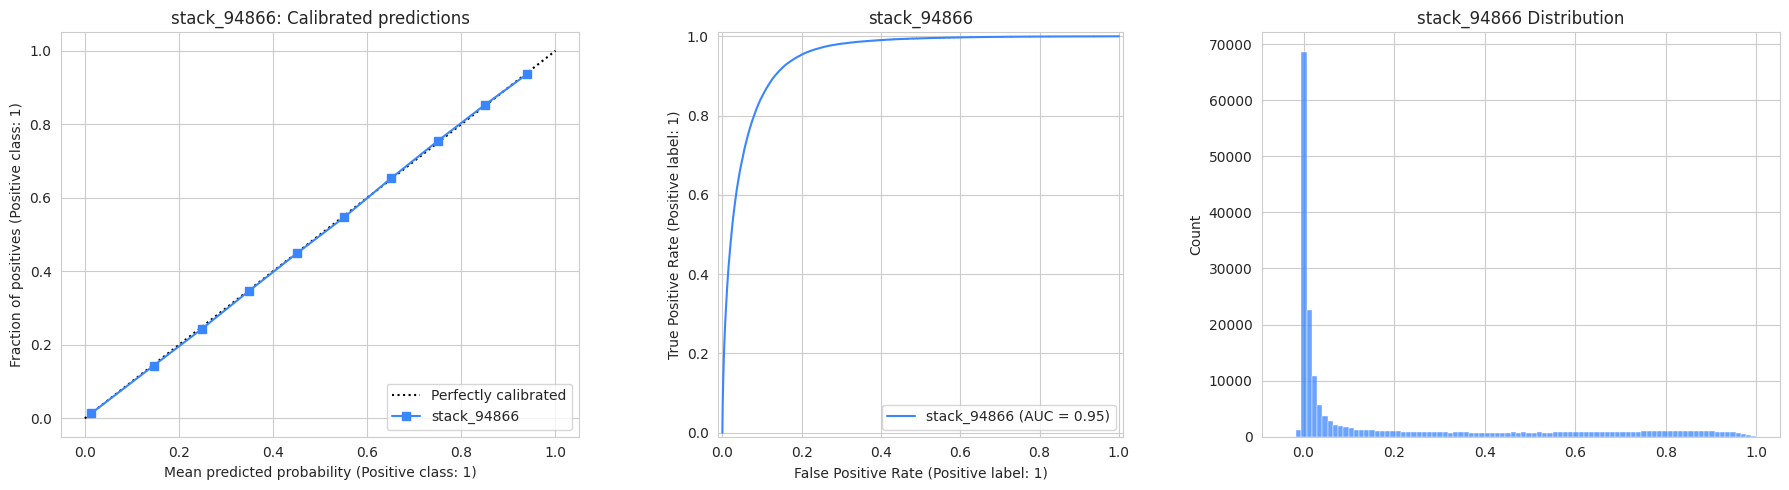

In [64]:
## -- Define Training Parameters --
stack_oof_preds  = np.zeros(len(oof_final))
stack_test_preds = np.zeros(len(test_final))
fold_scores = []

X = oof_final
y = train[TARGET]

## -- Initiate Training --
tik = time()
print(f"Stacking models: {X.shape[1]}")
for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f"Fold {fold+1}/{kfold.n_splits} | ", end='')
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test_final.copy()

    meta_model = RidgeCV(alphas=(0.1, 1.0, 10.0, 100.0), cv=5,
                         scoring='neg_root_mean_squared_error')
    meta_model.fit(X_train, y_train)
    stack_oof_preds[val_idx] = meta_model.predict(X_val)
    oof_score = np.round(roc_auc_score(y_val, meta_model.predict(X_val)), 5)
    fold_scores.append(oof_score)
    print(f"Score: {oof_score}")

    stack_test_preds += meta_model.predict(X_test)

stack_test_preds /= kfold.n_splits

tok = time()
tiktok = (tok-tik)

## -- After all folds --
stack_score = np.round(roc_auc_score(y, stack_oof_preds), 5)
stack_name = 'stack_' + str(stack_score).split('.')[1]

oof_final[stack_name]    = stack_oof_preds
test_final[stack_name]   = stack_test_preds
model_scores[stack_name] = stack_score

print(f"|{'-'*30}")
print(f"| OOF Score: {stack_score}")
print(f"| AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
print(f"|{'-'*30}")
print(f"| Time: {tiktok:.2f} secs")

_, axs = plt.subplots(1, 3, figsize=(18, 5))

CalibrationDisplay.from_predictions(y, stack_oof_preds.clip(0, 1), n_bins=10, name=stack_name, ax=axs[0])
axs[0].set_title(f"{stack_name}: Calibrated predictions")

# Left: ROC curve
RocCurveDisplay.from_predictions(y, stack_oof_preds, name=stack_name, ax=axs[1])
axs[1].set_title(f"{stack_name}")
# axs[1].grid(False)

sns.histplot(stack_test_preds, ax=axs[2])
axs[2].set_title(f"{stack_name} Distribution")

plt.tight_layout()
plt.show()

# ~ HILLCLIMB

In [65]:
try:
    from hillclimbers import climb_hill, partial
except:
    !pip install -q -U hillclimbers
    from hillclimbers import climb_hill, partial

  Preparing metadata (setup.py) ... done


In [66]:
%%time

## -- Run hillclimber --
hc_test_preds, hc_oof_preds = climb_hill(
        train=train,
        target=TARGET,
        oof_pred_df=oof_final.drop(columns=[stack_name]),
        test_pred_df=test_final.drop(columns=[stack_name]),
        eval_metric=partial(roc_auc_score),
        objective='maximize',
        return_oof_preds=True,
        negative_weights=True,
        precision=0.01,
        plot_hill=True,
        plot_hist=False,
)


   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (7 total): 

cat_94825:  0.94825 (best solo model)
xgb_94315:  0.94315
lgb_94291:  0.94291
hist_94252: 0.94252
rfc_93477:  0.93477
mlp_92592:  0.92592
log_91873:  0.91873

[Data preparation completed successfully] - [Initiate hill climbing] 

Iteration: 1 | Model added: rfc_93477 | Best weight: 0.11 | Best roc_auc_score: 0.94850
Iteration: 2 | Model added: xgb_94315 | Best weight: 0.14 | Best roc_auc_score: 0.94866
Iteration: 3 | Model added: mlp_92592 | Best weight: 0.04 | Best roc_auc_score: 0.94870
Iteration: 4 | Model added: log_91873 | Best weight: -0.03 | Best roc_auc_score: 0.94874
Iteration: 5 | Model added: hist_94252 | Best weight: -0.02 | Best roc_auc_score: 0.94874


CPU times: user 4min 14s, sys: 1.26 s, total: 4min 15s
Wall time: 4min 16s


In [67]:
hc_score = np.round(roc_auc_score(y, hc_oof_preds), 5)
hc_name = 'hill_' + str(hc_score).split('.')[1]

oof_final[hc_name]  = hc_oof_preds
test_final[hc_name] = hc_test_preds

model_scores[hc_name] = hc_score
model_scores.sort_values(inplace=True)
model_scores

log_91873      0.91873
mlp_92592      0.92592
rfc_93477      0.93477
hist_94252     0.94252
lgb_94291      0.94291
xgb_94315      0.94315
cat_94825      0.94825
stack_94866    0.94866
hill_94874     0.94874
dtype: float64

,xgb_94315,lgb_94291,cat_94825,rfc_93477,hist_94252,log_91873,mlp_92592,stack_94866,hill_94874
0,0.746657,0.748463,0.834372,0.76,0.767608,0.815661,0.292217,0.800969,0.794015
1,0.631101,0.354439,0.808303,0.62,0.354168,0.186076,0.257834,0.789541,0.770306
2,0.294776,0.459581,0.473768,0.56,0.513137,0.550073,0.289026,0.445544,0.445836
3,0.002197,0.002162,0.001907,0.02,0.003014,0.000136,0.000436,0.001275,0.003645
4,0.214494,0.276609,0.293393,0.30,0.250733,0.323191,0.150565,0.275923,0.276822


,xgb_94315,lgb_94291,cat_94825,rfc_93477,hist_94252,log_91873,mlp_92592,stack_94866,hill_94874
0,0.006809,0.005044,0.005361,0.006,0.005338,0.000530,0.003442,0.003511,0.005694
1,0.001741,0.003141,0.002533,0.002,0.003133,0.000723,0.006368,0.000175,0.002575
2,0.002608,0.005067,0.005205,0.000,0.004781,0.000667,0.009136,0.002284,0.004654
3,0.138310,0.124470,0.205295,0.278,0.125371,0.634451,0.132810,0.169004,0.188193
4,0.793360,0.732768,0.842599,0.782,0.762264,0.563747,0.687571,0.848831,0.833489


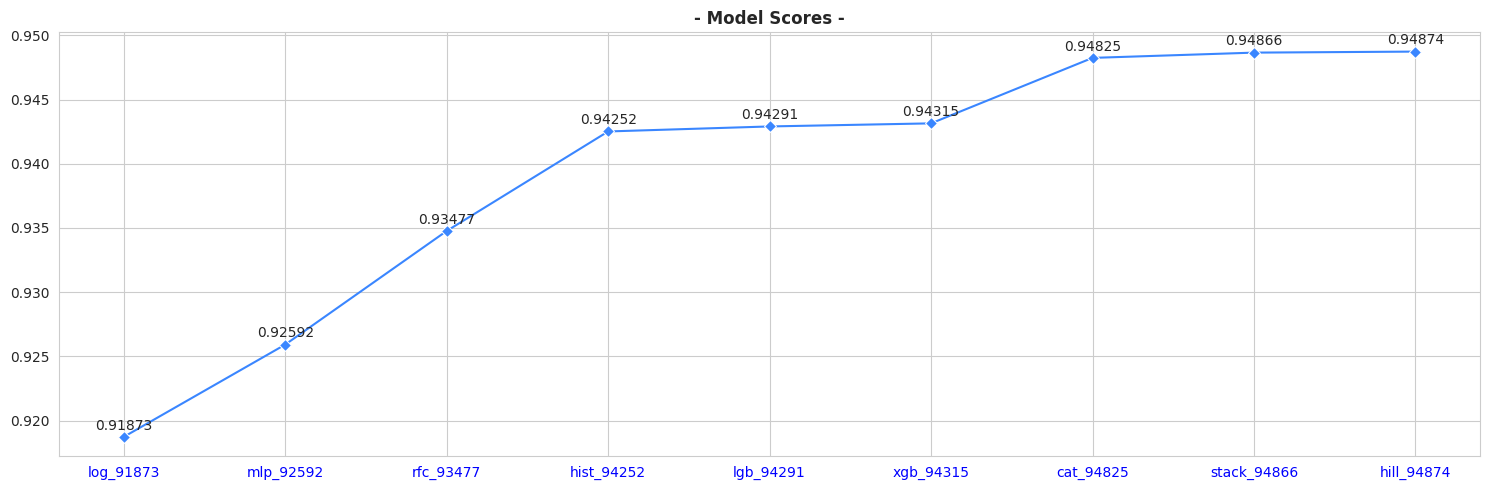

In [68]:
display(oof_final.head())
print()
display(test_final.head())
print()
plt.figure(figsize=(15, 5))
sns.lineplot(model_scores.sort_values(), marker='D')
plt.tick_params(axis='x', labelcolor='b')
plt.title('- Model Scores -', fontweight='bold')

for i, s in enumerate(model_scores.values):
    plt.text(model_scores.index[i], s+1e-3, s, va='center_baseline', ha='center')

plt.tight_layout()
plt.show()

# SUBMISSION

In [69]:
## -- Export stacking --
s_score = str(stack_score).split('.')[1]
s_oof = oof_final[stack_name].to_numpy().ravel()
s_test = test_final[stack_name].to_numpy().ravel()

stack_oof  = f"oof_BASE_stack_{s_score}.npy"
stack_pred = f"test_BASE_stack_{s_score}.npy"

np.save(stack_oof, s_oof)
np.save(stack_pred, s_test)

print(stack_oof, stack_pred)

oof_BASE_stack_94866.npy test_BASE_stack_94866.npy


In [70]:
## -- Export hillclimb --
h_score = str(hc_score).split('.')[1]
h_oof = oof_final[hc_name].to_numpy().ravel()
h_test = test_final[hc_name].to_numpy().ravel()

hill_oof  = f"oof_BASE_hill_{h_score}.npy"
hill_pred = f"test_BASE_hill_{h_score}.npy"

np.save(hill_oof, h_oof)
np.save(hill_pred, h_test)

print(hill_oof, hill_pred)

oof_BASE_hill_94874.npy test_BASE_hill_94874.npy


In [71]:
## -- Create Submission files --
for i, c in enumerate(test_final.columns):
    submit[TARGET] = test_final[c].values.ravel()
    submit.to_csv(f"submit_BASE_{c}.csv", index=False)
    print(f" -> submit_BASE_{c}.csv file saved!")

 -> submit_BASE_xgb_94315.csv file saved!
 -> submit_BASE_lgb_94291.csv file saved!
 -> submit_BASE_cat_94825.csv file saved!
 -> submit_BASE_rfc_93477.csv file saved!
 -> submit_BASE_hist_94252.csv file saved!
 -> submit_BASE_log_91873.csv file saved!
 -> submit_BASE_mlp_92592.csv file saved!
 -> submit_BASE_stack_94866.csv file saved!
 -> submit_BASE_hill_94874.csv file saved!
